In [ ]:
!pip install evaluate -q

import warnings
warnings.filterwarnings('ignore')

import json
import zipfile
import hashlib
import matplotlib.pyplot as plt
import pandas as pd
import os
import uuid
import re
import random
import shutil
import cv2
import evaluate
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img, array_to_img
from google.colab import drive
from google.colab import files
from pathlib import Path
from PIL import Image, ImageStat, UnidentifiedImageError
from matplotlib import patches
from tqdm import tqdm
from collections import Counter
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchsummary import summary
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix, roc_curve, precision_score, recall_score, f1_score, precision_recall_fscore_support, auc
from datasets import Dataset
from transformers import AutoImageProcessor, AutoModelForImageClassification, TrainingArguments, Trainer, DefaultDataCollator, AutoConfig
from IPython.display import display

import torch, numpy as np, random
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.backends.cudnn.deterministic = True
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True # Picks the fastest convolution algorithm for your GPU, so keep it True

print("Libraries imported - ready to use PyTorch", torch.__version__)

Libraries imported - ready to use PyTorch 2.8.0+cu126


In [ ]:
drive.mount('/content/drive')
zip_path = '/content/drive/MyDrive/Vehicles.zip'
extract_to = '/content/my_data'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

Mounted at /content/drive


In [ ]:
image_extensions = {'.jpg', '.jpeg', '.png'}
paths = [(path.parts[-2], path.name, str(path)) for path in Path(extract_to).rglob('*.*') if path.suffix.lower() in image_extensions]

df = pd.DataFrame(paths, columns = ['class', 'image', 'full_path'])
df = df.sort_values('class', ascending = True)
df.reset_index(drop = True, inplace = True)
df

,class,image,full_path
0,Auto Rickshaws,Auto Rickshaw (312).jpg,/content/my_data/Vehicles/Auto Rickshaws/Auto ...
1,Auto Rickshaws,Auto Rickshaw (36).jpg,/content/my_data/Vehicles/Auto Rickshaws/Auto ...
2,Auto Rickshaws,Auto Rickshaw (737).jpg,/content/my_data/Vehicles/Auto Rickshaws/Auto ...
3,Auto Rickshaws,Auto Rickshaw (702).jpg,/content/my_data/Vehicles/Auto Rickshaws/Auto ...
4,Auto Rickshaws,Auto Rickshaw (180).jpg,/content/my_data/Vehicles/Auto Rickshaws/Auto ...
...,...,...,...
5582,Trains,Train (362).jpg,/content/my_data/Vehicles/Trains/Train (362).jpg
5583,Trains,Train (22).jpg,/content/my_data/Vehicles/Trains/Train (22).jpg
5584,Trains,Train (663).jpg,/content/my_data/Vehicles/Trains/Train (663).jpg
5585,Trains,Train (218).png,/content/my_data/Vehicles/Trains/Train (218).png


In [ ]:
# Check number of each file extension
df['extension'] = df['image'].apply(lambda x: Path(x).suffix.lower())
extension_counts = df['extension'].value_counts()

print("Image extension distribution:")
print(extension_counts)

invalid_exts = df[~df['extension'].isin(['.jpg', '.jpeg', '.png'])]
print("Invalid extensions found:")
print(invalid_exts[['class', 'image']])

Image extension distribution:
extension
.jpg    5070
.png     517
Name: count, dtype: int64
Invalid extensions found:
Empty DataFrame
Columns: [class, image]
Index: []


In [ ]:
# Define valid target extension
target_ext = ".jpg"

# Loop through all images in your dataframe
for old_path in tqdm(df['full_path'], desc="Converting images"):
    old_path = Path(old_path)
    new_path = old_path.with_suffix(target_ext)

    try:
        # Open image and convert to RGB (to avoid "RGBA" or "P" mode issues) Because I just applied EDA before to the same dataset and I found these modes
        with Image.open(old_path) as img:
            img = img.convert("RGB")
            img.save(new_path, quality=95)

        # If converted successfully and name changed, delete old one
        if old_path != new_path:
            os.remove(old_path)

    except Exception as e:
        print(f"Error converting {old_path}: {e}")

print("All images converted to .jpg successfully!")

Converting images: 100%|██████████| 5587/5587 [01:42<00:00, 54.59it/s]

All images converted to .jpg successfully!


In [ ]:
image_extensions = {'.jpg', '.jpeg', '.png'}
paths = [(path.parts[-2], path.name, str(path)) for path in Path(extract_to).rglob('*.*') if path.suffix.lower() in image_extensions]

df = pd.DataFrame(paths, columns = ['class', 'image', 'full_path'])
df = df.sort_values('class', ascending = True)
df.reset_index(drop = True, inplace = True)
df

,class,image,full_path
0,Auto Rickshaws,Auto Rickshaw (312).jpg,/content/my_data/Vehicles/Auto Rickshaws/Auto ...
1,Auto Rickshaws,Auto Rickshaw (318).jpg,/content/my_data/Vehicles/Auto Rickshaws/Auto ...
2,Auto Rickshaws,Auto Rickshaw (474).jpg,/content/my_data/Vehicles/Auto Rickshaws/Auto ...
3,Auto Rickshaws,Auto Rickshaw (573).jpg,/content/my_data/Vehicles/Auto Rickshaws/Auto ...
4,Auto Rickshaws,Auto Rickshaw (36).jpg,/content/my_data/Vehicles/Auto Rickshaws/Auto ...
...,...,...,...
5582,Trains,Train (362).jpg,/content/my_data/Vehicles/Trains/Train (362).jpg
5583,Trains,Train (22).jpg,/content/my_data/Vehicles/Trains/Train (22).jpg
5584,Trains,Train (663).jpg,/content/my_data/Vehicles/Trains/Train (663).jpg
5585,Trains,Train (629).jpg,/content/my_data/Vehicles/Trains/Train (629).jpg


In [ ]:
# Check number of each file extension
df['extension'] = df['image'].apply(lambda x: Path(x).suffix.lower())
extension_counts = df['extension'].value_counts()

print("Image extension distribution:")
print(extension_counts)

Image extension distribution:
extension
.jpg    5587
Name: count, dtype: int64


In [ ]:
# Count per class
class_count = df['class'].value_counts()
for cls, count in class_count.items():
    print(f'Class: {cls}, Count: {count} images')

print(f"\nTotal dataset size is: {len(df)} images")
print(f"Number of classes: {df['class'].nunique()} classes")

extensions = [os.path.splitext(fname)[1].lower() for fname in df['image']]
ext_count = Counter(extensions)

print("\nImage format distribution:")
for ext, count in ext_count.items():
    print(f"Extension: {ext}, Count: {count} images")

Class: Auto Rickshaws, Count: 800 images
Class: Bikes, Count: 800 images
Class: Motorcycles, Count: 800 images
Class: Trains, Count: 800 images
Class: Ships, Count: 800 images
Class: Planes, Count: 797 images
Class: Cars, Count: 790 images

Total dataset size is: 5587 images
Number of classes: 7 classes

Image format distribution:
Extension: .jpg, Count: 5587 images


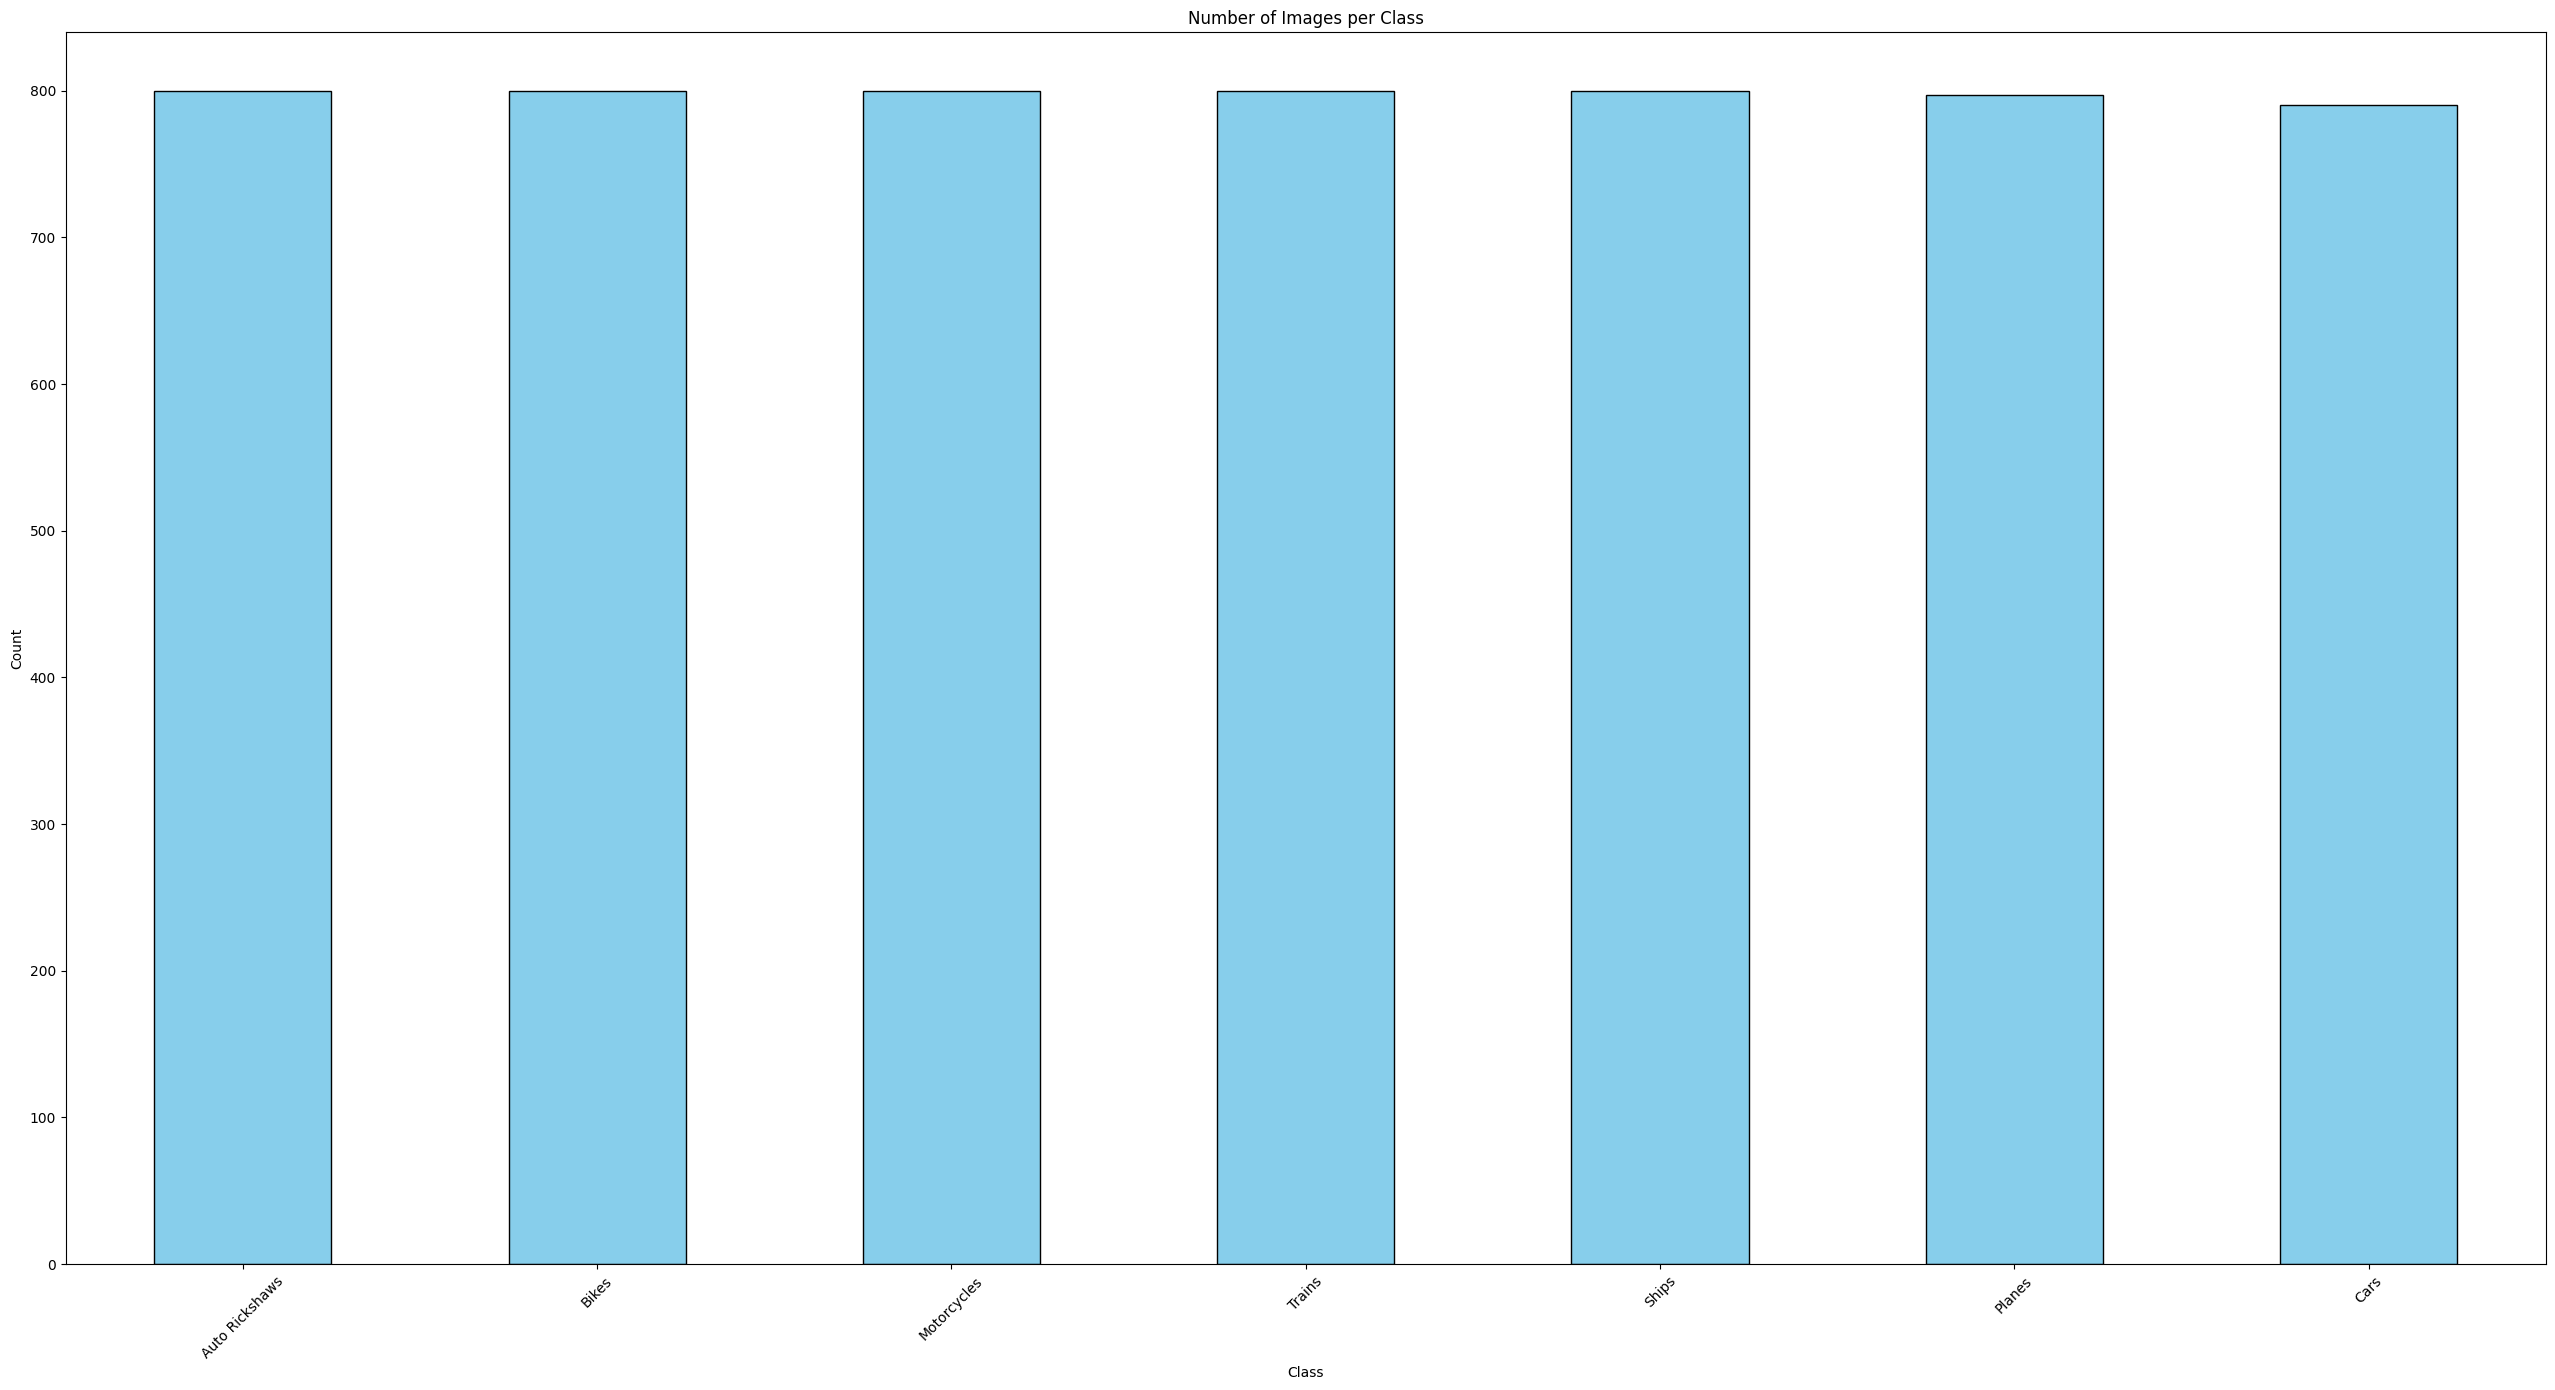

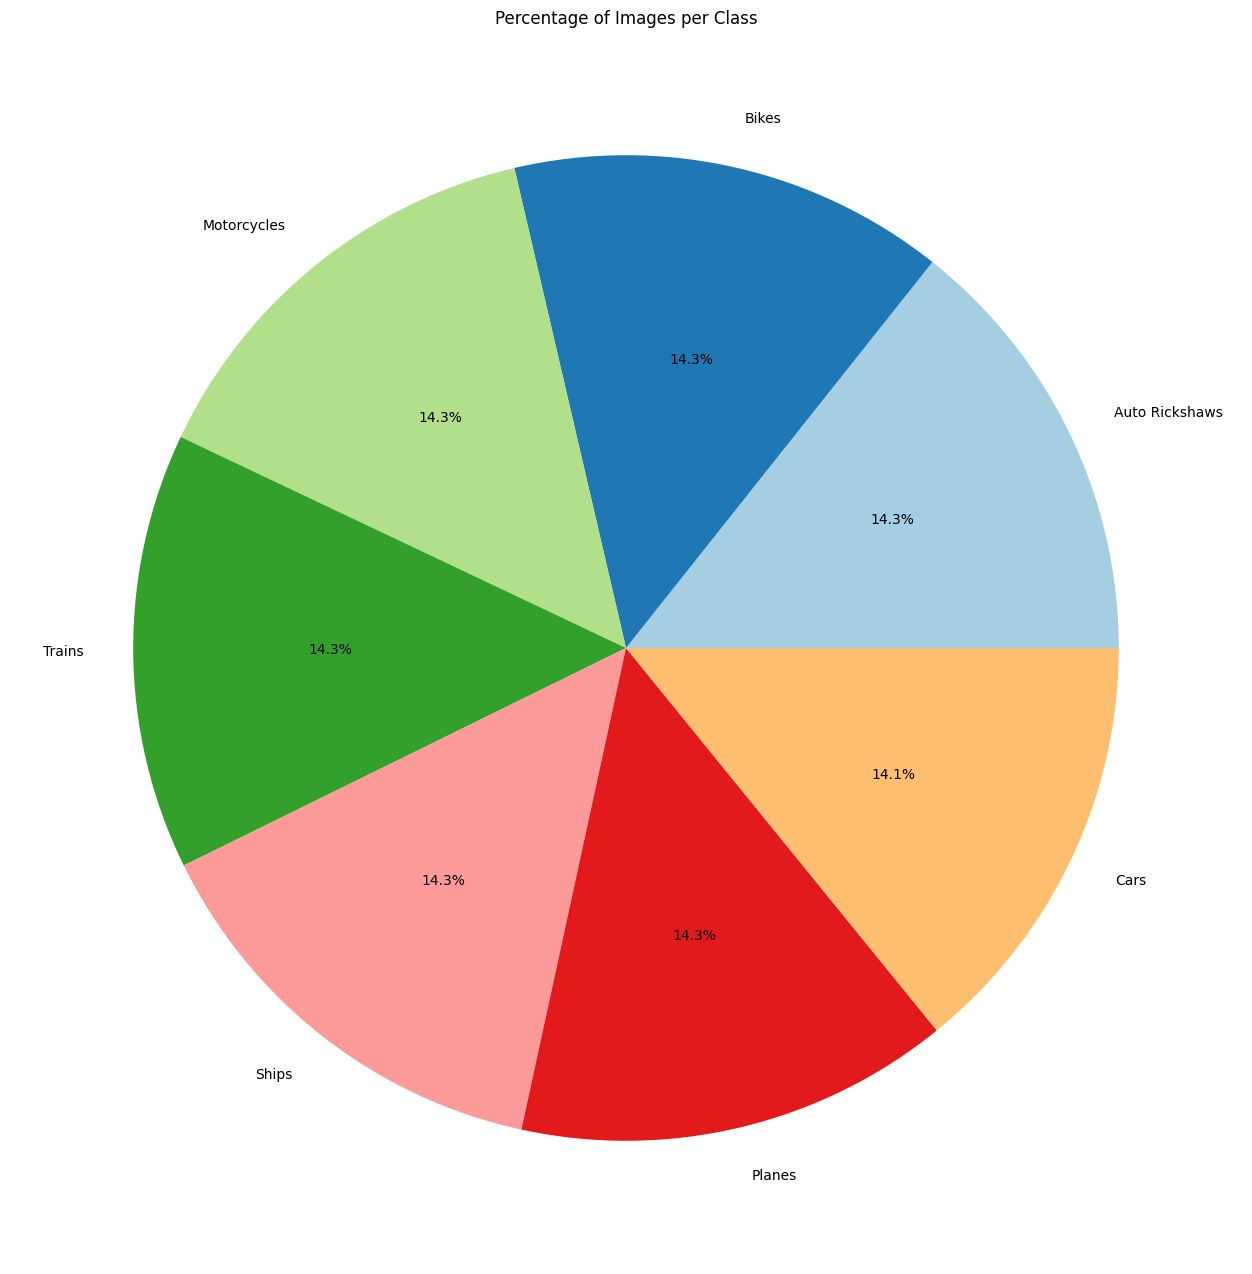

In [ ]:
plt.figure(figsize = (32, 16))
class_count.plot(kind = 'bar', color = 'skyblue', edgecolor = 'black')
plt.title('Number of Images per Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation = 45)
plt.show()

plt.figure(figsize = (32, 16))
class_count.plot(kind = 'pie', autopct = '%1.1f%%', colors = plt.cm.Paired.colors)
plt.title('Percentage of Images per Class')
plt.ylabel('')
plt.show()

                Count  Percentage %
class                              
Auto Rickshaws    800         14.32
Bikes             800         14.32
Motorcycles       800         14.32
Trains            800         14.32
Ships             800         14.32
Planes            797         14.27
Cars              790         14.14


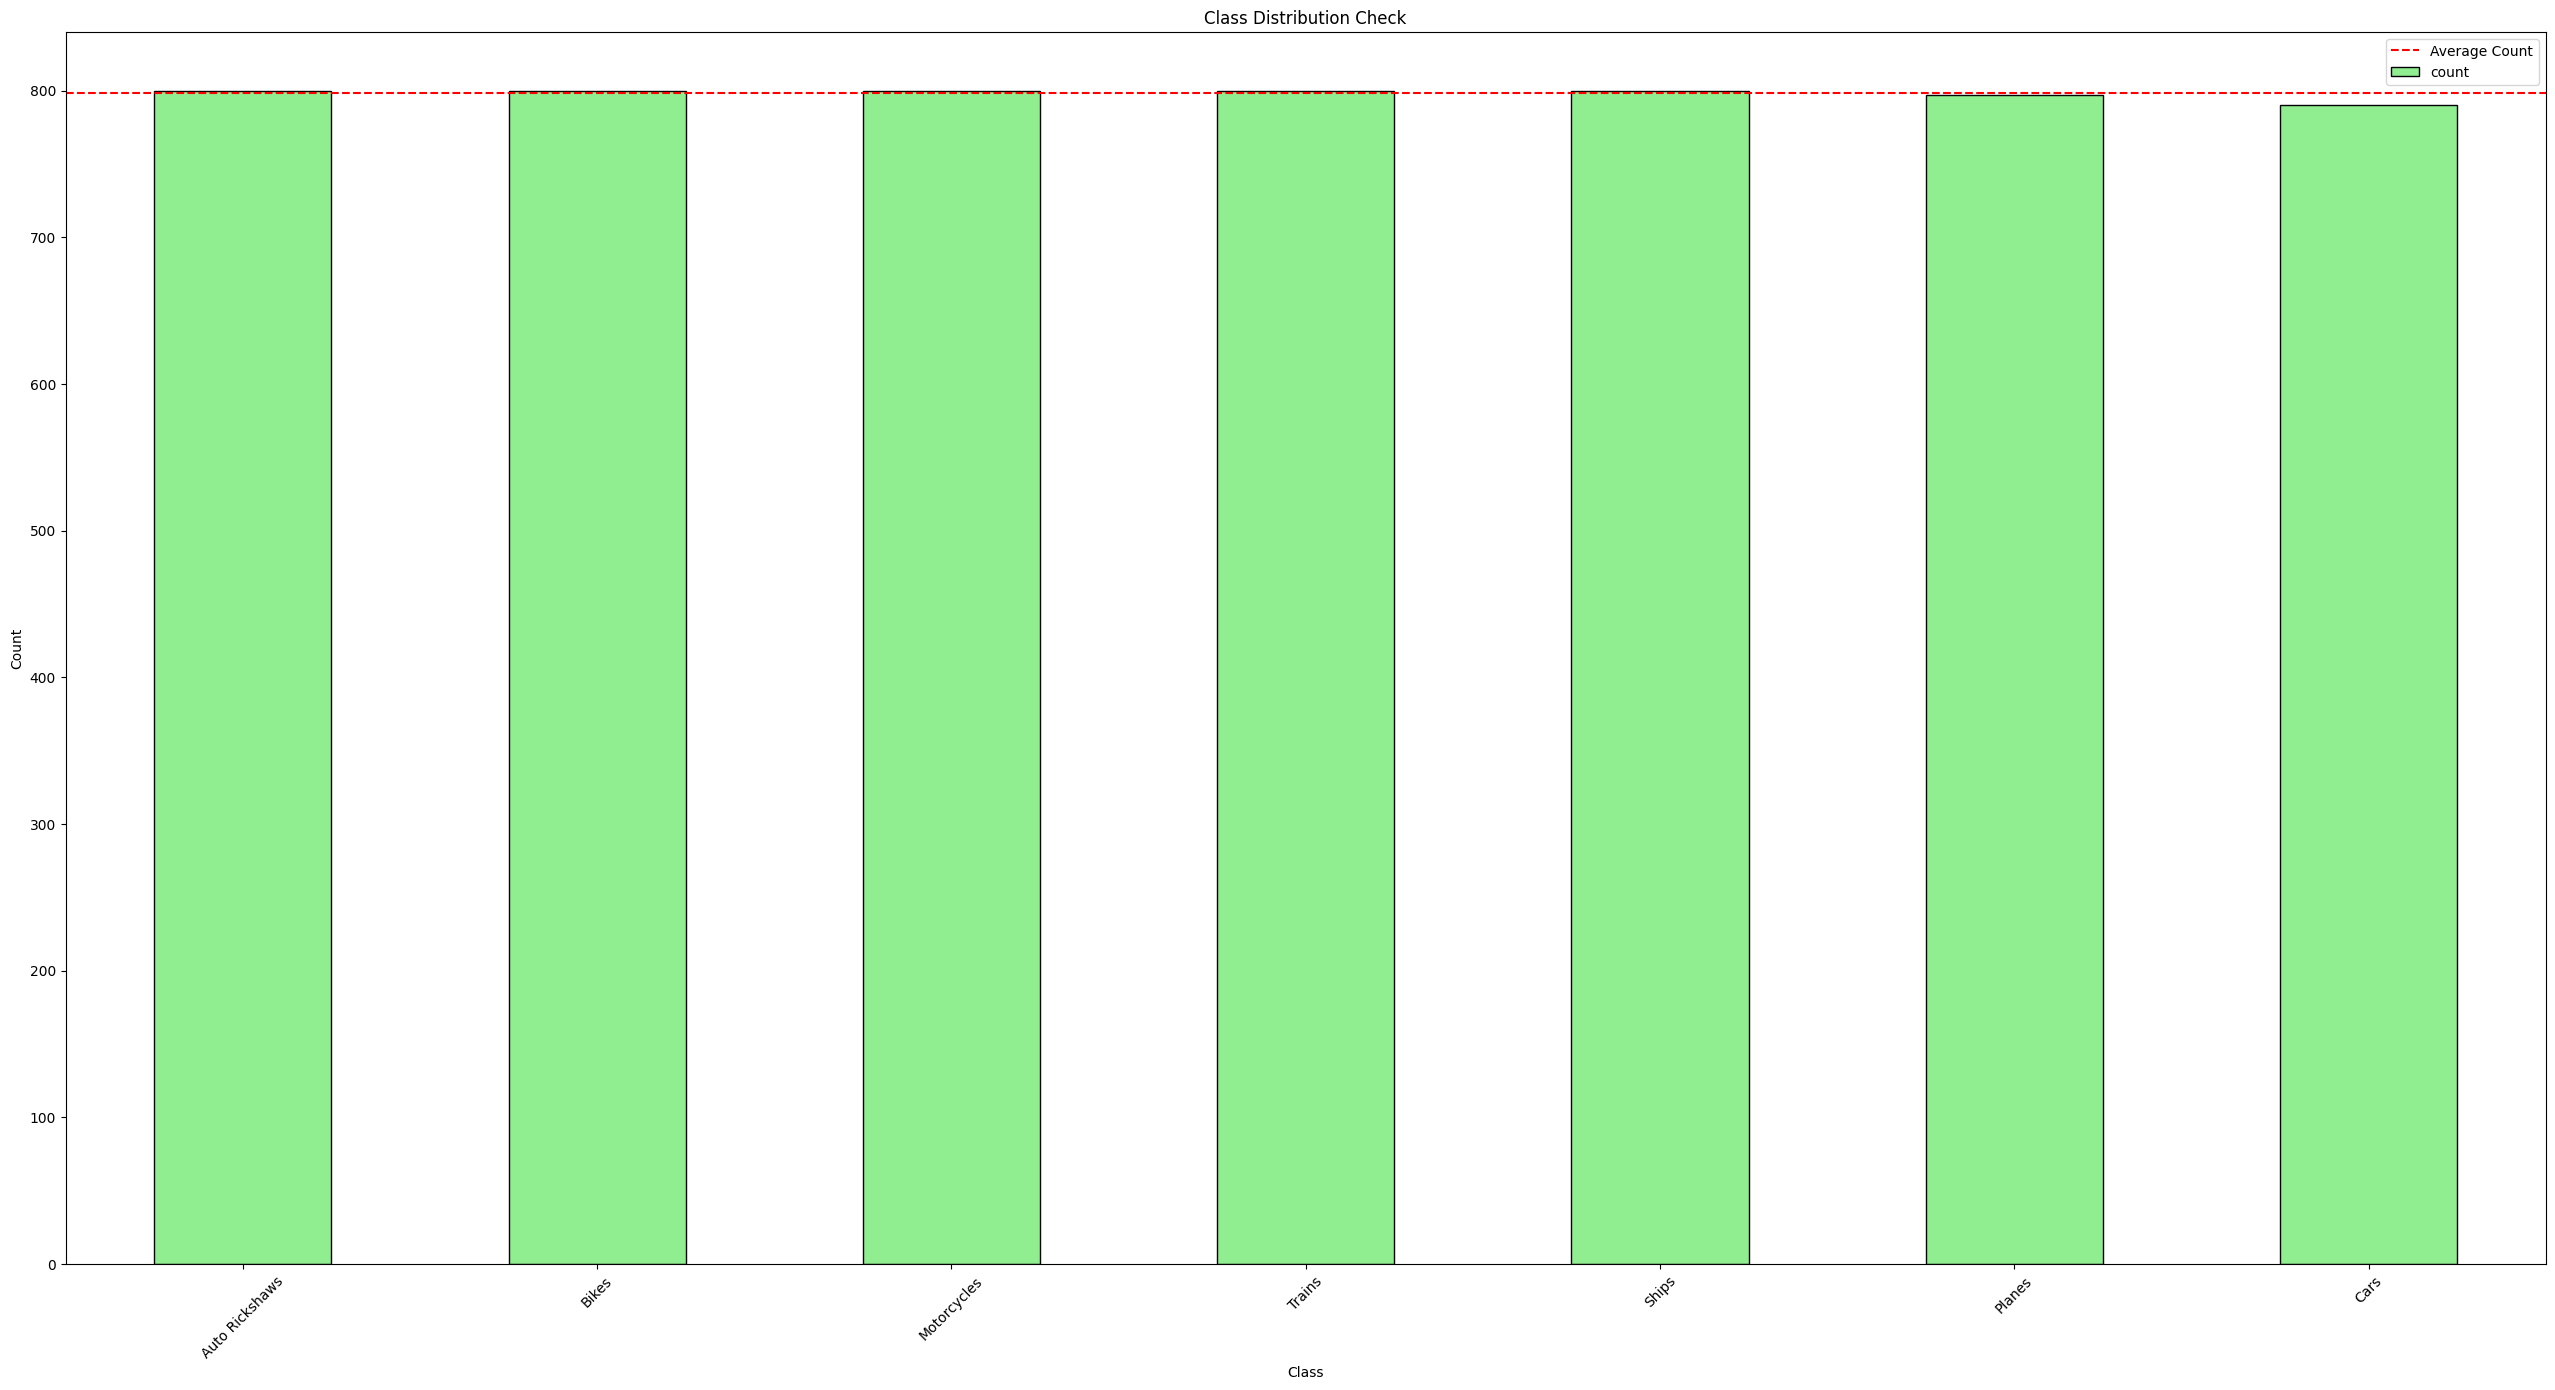

In [ ]:
percentages = (class_count / len(df)) * 100
imbalance_df = pd.DataFrame({'Count': class_count, 'Percentage %': percentages.round(2)})
print(imbalance_df)

plt.figure(figsize = (32, 16))
class_count.plot(kind = 'bar', color = 'lightgreen', edgecolor = 'black')
plt.title('Class Distribution Check')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation = 45)
plt.axhline(y = class_count.mean(), color = 'red', linestyle = '--', label = 'Average Count')
plt.legend()

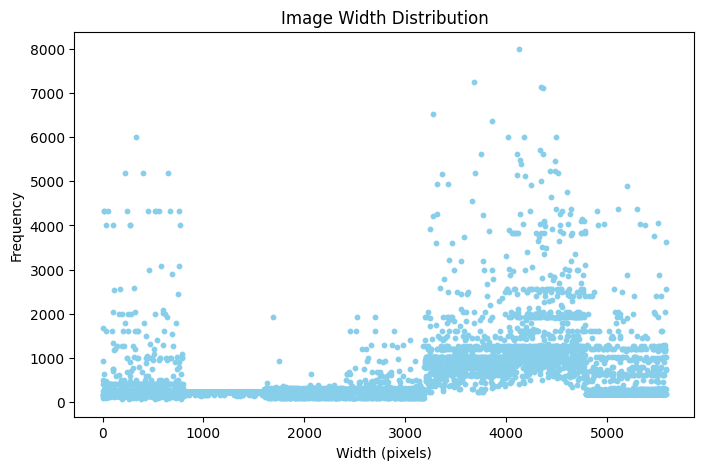

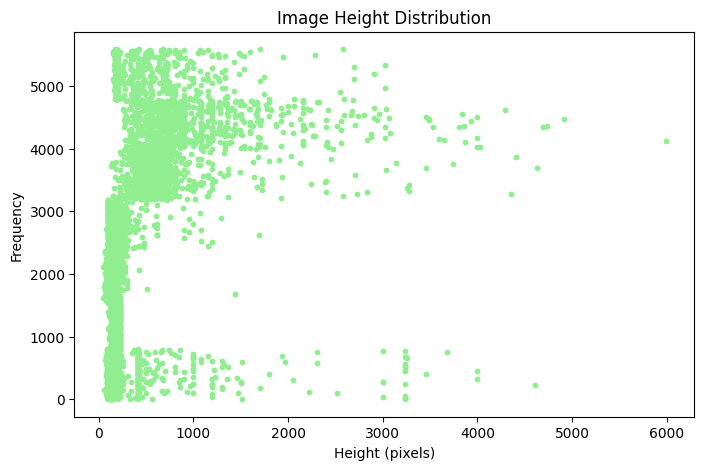

      Width  Height  Count
0       192     192    426
1       225     169    379
2       275     183    353
3       300     168    186
4       100     100    139
...     ...     ...    ...
1726    800     502      1
1727    800     497      1
1728    800     496      1
1729    800     494      1
1730    800     514      1

[1731 rows x 3 columns]
Image Mode Distribution:
Mode
RGB    5587
Name: count, dtype: int64

Number of Channels Distribution:
Channels
3    5587
Name: count, dtype: int64


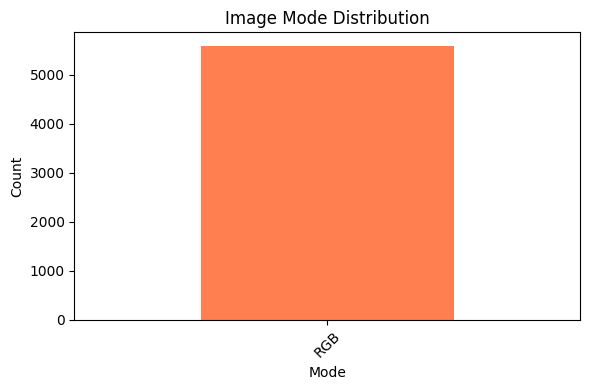

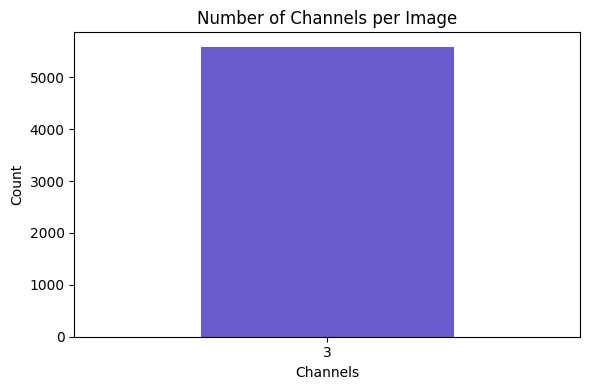

In [ ]:
image_sizes = []

for file_path in df['full_path']:
    with Image.open(file_path) as img:
        image_sizes.append(img.size)

sizes_df = pd.DataFrame(image_sizes, columns=['Width', 'Height'])

#Width
plt.figure(figsize=(8,5))
plt.scatter(x = range(len(sizes_df)), y = sizes_df['Width'], color='skyblue', s=10)
plt.title('Image Width Distribution')
plt.xlabel('Width (pixels)')
plt.ylabel('Frequency')
plt.show()

#Height
plt.figure(figsize=(8,5))
plt.scatter(x = sizes_df['Height'], y = range(len(sizes_df)), color='lightgreen', s=10)
plt.title('Image Height Distribution')
plt.xlabel('Height (pixels)')
plt.ylabel('Frequency')
plt.show()

#For best sure the size of the whole images
unique_sizes = sizes_df.value_counts().reset_index(name='Count')
print(unique_sizes)

image_data = []

for file_path in df['full_path']:
    with Image.open(file_path) as img:
        width, height = img.size
        mode = img.mode  # e.g., 'RGB', 'L', 'RGBA', etc.
        channels = len(img.getbands())  # Number of channels
        image_data.append((width, height, mode, channels))

# Create DataFrame
image_df = pd.DataFrame(image_data, columns=['Width', 'Height', 'Mode', 'Channels'])

print("Image Mode Distribution:")
print(image_df['Mode'].value_counts())

print("\nNumber of Channels Distribution:")
print(image_df['Channels'].value_counts())

plt.figure(figsize=(6,4))
image_df['Mode'].value_counts().plot(kind='bar', color='coral')
plt.title("Image Mode Distribution")
plt.xlabel("Mode")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
image_df['Channels'].value_counts().sort_index().plot(kind='bar', color='slateblue')
plt.title("Number of Channels per Image")
plt.xlabel("Channels")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Target directory for balanced dataset
balanced_dir = "/content/my_data_balanced"
os.makedirs(balanced_dir, exist_ok=True)

# Define augmentation generator
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

target_count = 800  # max per class

for cls in tqdm(df['class'].unique(), desc="Balancing classes"):
    class_df = df[df['class'] == cls]
    class_paths = class_df['full_path'].tolist()
    class_dir = os.path.join(balanced_dir, cls)
    os.makedirs(class_dir, exist_ok=True)

    # Copy originals first
    for path in class_paths:
        shutil.copy(path, class_dir)

    current_count = len(class_paths)
    if current_count >= target_count:
        continue

    num_to_generate = target_count - current_count
    gen_count = 0

    # Cycle through original images until we reach target_count
    while gen_count < num_to_generate:
        for img_path in class_paths:
            if gen_count >= num_to_generate:
                break

            img = load_img(img_path, target_size=(500, 500))
            x = img_to_array(img)
            x = np.expand_dims(x, axis=0)

            # Just one augmented version per image at a time
            batch = next(datagen.flow(x, batch_size=1))
            base_name = os.path.splitext(os.path.basename(img_path))[0]
            new_filename = f"aug_{base_name}_{uuid.uuid4().hex}.jpg"
            save_path = os.path.join(class_dir, new_filename)
            array_to_img(batch[0]).save(save_path)

            gen_count += 1

print("\nDataset balanced and saved at:", balanced_dir)

Balancing classes: 100%|██████████| 7/7 [00:11<00:00,  1.63s/it]


Dataset balanced and saved at: /content/my_data_balanced


In [ ]:
image_extensions = {'.jpg', '.jpeg', '.png'}
paths = [(path.parts[-2], path.name, str(path)) for path in Path(balanced_dir).rglob('*.*') if path.suffix.lower() in image_extensions]

df = pd.DataFrame(paths, columns = ['class', 'image', 'full_path'])
df = df.sort_values('class', ascending = True)
df.reset_index(drop = True, inplace = True)
df

,class,image,full_path
0,Auto Rickshaws,Auto Rickshaw (312).jpg,/content/my_data_balanced/Auto Rickshaws/Auto ...
1,Auto Rickshaws,Auto Rickshaw (318).jpg,/content/my_data_balanced/Auto Rickshaws/Auto ...
2,Auto Rickshaws,Auto Rickshaw (474).jpg,/content/my_data_balanced/Auto Rickshaws/Auto ...
3,Auto Rickshaws,Auto Rickshaw (573).jpg,/content/my_data_balanced/Auto Rickshaws/Auto ...
4,Auto Rickshaws,Auto Rickshaw (36).jpg,/content/my_data_balanced/Auto Rickshaws/Auto ...
...,...,...,...
5595,Trains,Train (362).jpg,/content/my_data_balanced/Trains/Train (362).jpg
5596,Trains,Train (22).jpg,/content/my_data_balanced/Trains/Train (22).jpg
5597,Trains,Train (663).jpg,/content/my_data_balanced/Trains/Train (663).jpg
5598,Trains,Train (629).jpg,/content/my_data_balanced/Trains/Train (629).jpg


In [ ]:
# Count per class
class_count = df['class'].value_counts()
for cls, count in class_count.items():
    print(f'Class: {cls}, Count: {count} images')

print(f"\nTotal dataset size is: {len(df)} images")
print(f"Number of classes: {df['class'].nunique()} classes")

extensions = [os.path.splitext(fname)[1].lower() for fname in df['image']]
ext_count = Counter(extensions)

print("\nImage format distribution:")
for ext, count in ext_count.items():
    print(f"Extension: {ext}, Count: {count} images")

Class: Auto Rickshaws, Count: 800 images
Class: Bikes, Count: 800 images
Class: Cars, Count: 800 images
Class: Motorcycles, Count: 800 images
Class: Planes, Count: 800 images
Class: Ships, Count: 800 images
Class: Trains, Count: 800 images

Total dataset size is: 5600 images
Number of classes: 7 classes

Image format distribution:
Extension: .jpg, Count: 5600 images


In [ ]:
# Pick a random class to visualize
random_class = random.choice(df['class'].unique())
class_df = df[df['class'] == random_class]

# Map originals to their augmentations
pairs = []
for orig_path in class_df[~class_df['image'].str.startswith("aug_")]['full_path']:
    base_name = os.path.splitext(os.path.basename(orig_path))[0]
    # Find all augmentations containing this base_name
    related_augs = class_df[class_df['image'].str.contains(f"aug_{base_name}")]['full_path'].tolist()
    if related_augs:
        pairs.append((orig_path, random.choice(related_augs)))  # pick one augmentation

# Pick up to 5 pairs
pairs = random.sample(pairs, min(5, len(pairs)))

plt.figure(figsize=(32, 16))
for i, (orig, aug) in enumerate(pairs):
    # Show original
    plt.subplot(len(pairs), 2, 2*i+1)
    plt.imshow(Image.open(orig).convert("RGB"))
    plt.title(f"{random_class} (Original)")
    plt.axis("off")

    # Show augmented
    plt.subplot(len(pairs), 2, 2*i+2)
    plt.imshow(Image.open(aug).convert("RGB"))
    plt.title(f"{random_class} (Augmented)")
    plt.axis("off")

plt.tight_layout()
plt.show()

<Figure size 3200x1600 with 0 Axes>

Image: Ship (792).jpg | Class: Ships | Size: 3099x2066 | Brightness: 91.6 | Contrast: 53.7
Image: Ship (14).jpg | Class: Ships | Size: 1440x576 | Brightness: 127.5 | Contrast: 65.8
Image: Car (395).jpg | Class: Cars | Size: 275x183 | Brightness: 112.0 | Contrast: 75.2
Image: Motorcycle (660).jpg | Class: Motorcycles | Size: 275x183 | Brightness: 118.1 | Contrast: 48.8
Image: Motorcycle (510).jpg | Class: Motorcycles | Size: 300x168 | Brightness: 197.6 | Contrast: 85.5
Image: Ship (685).jpg | Class: Ships | Size: 825x1170 | Brightness: 102.6 | Contrast: 56.5
Image: Car (79).jpg | Class: Cars | Size: 284x178 | Brightness: 35.5 | Contrast: 69.9
Image: Car (622).jpg | Class: Cars | Size: 297x170 | Brightness: 224.8 | Contrast: 64.1
Image: Plane (730).jpg | Class: Planes | Size: 1920x1020 | Brightness: 168.8 | Contrast: 62.8
Image: Bike (545).jpg | Class: Bikes | Size: 225x169 | Brightness: 144.9 | Contrast: 62.1


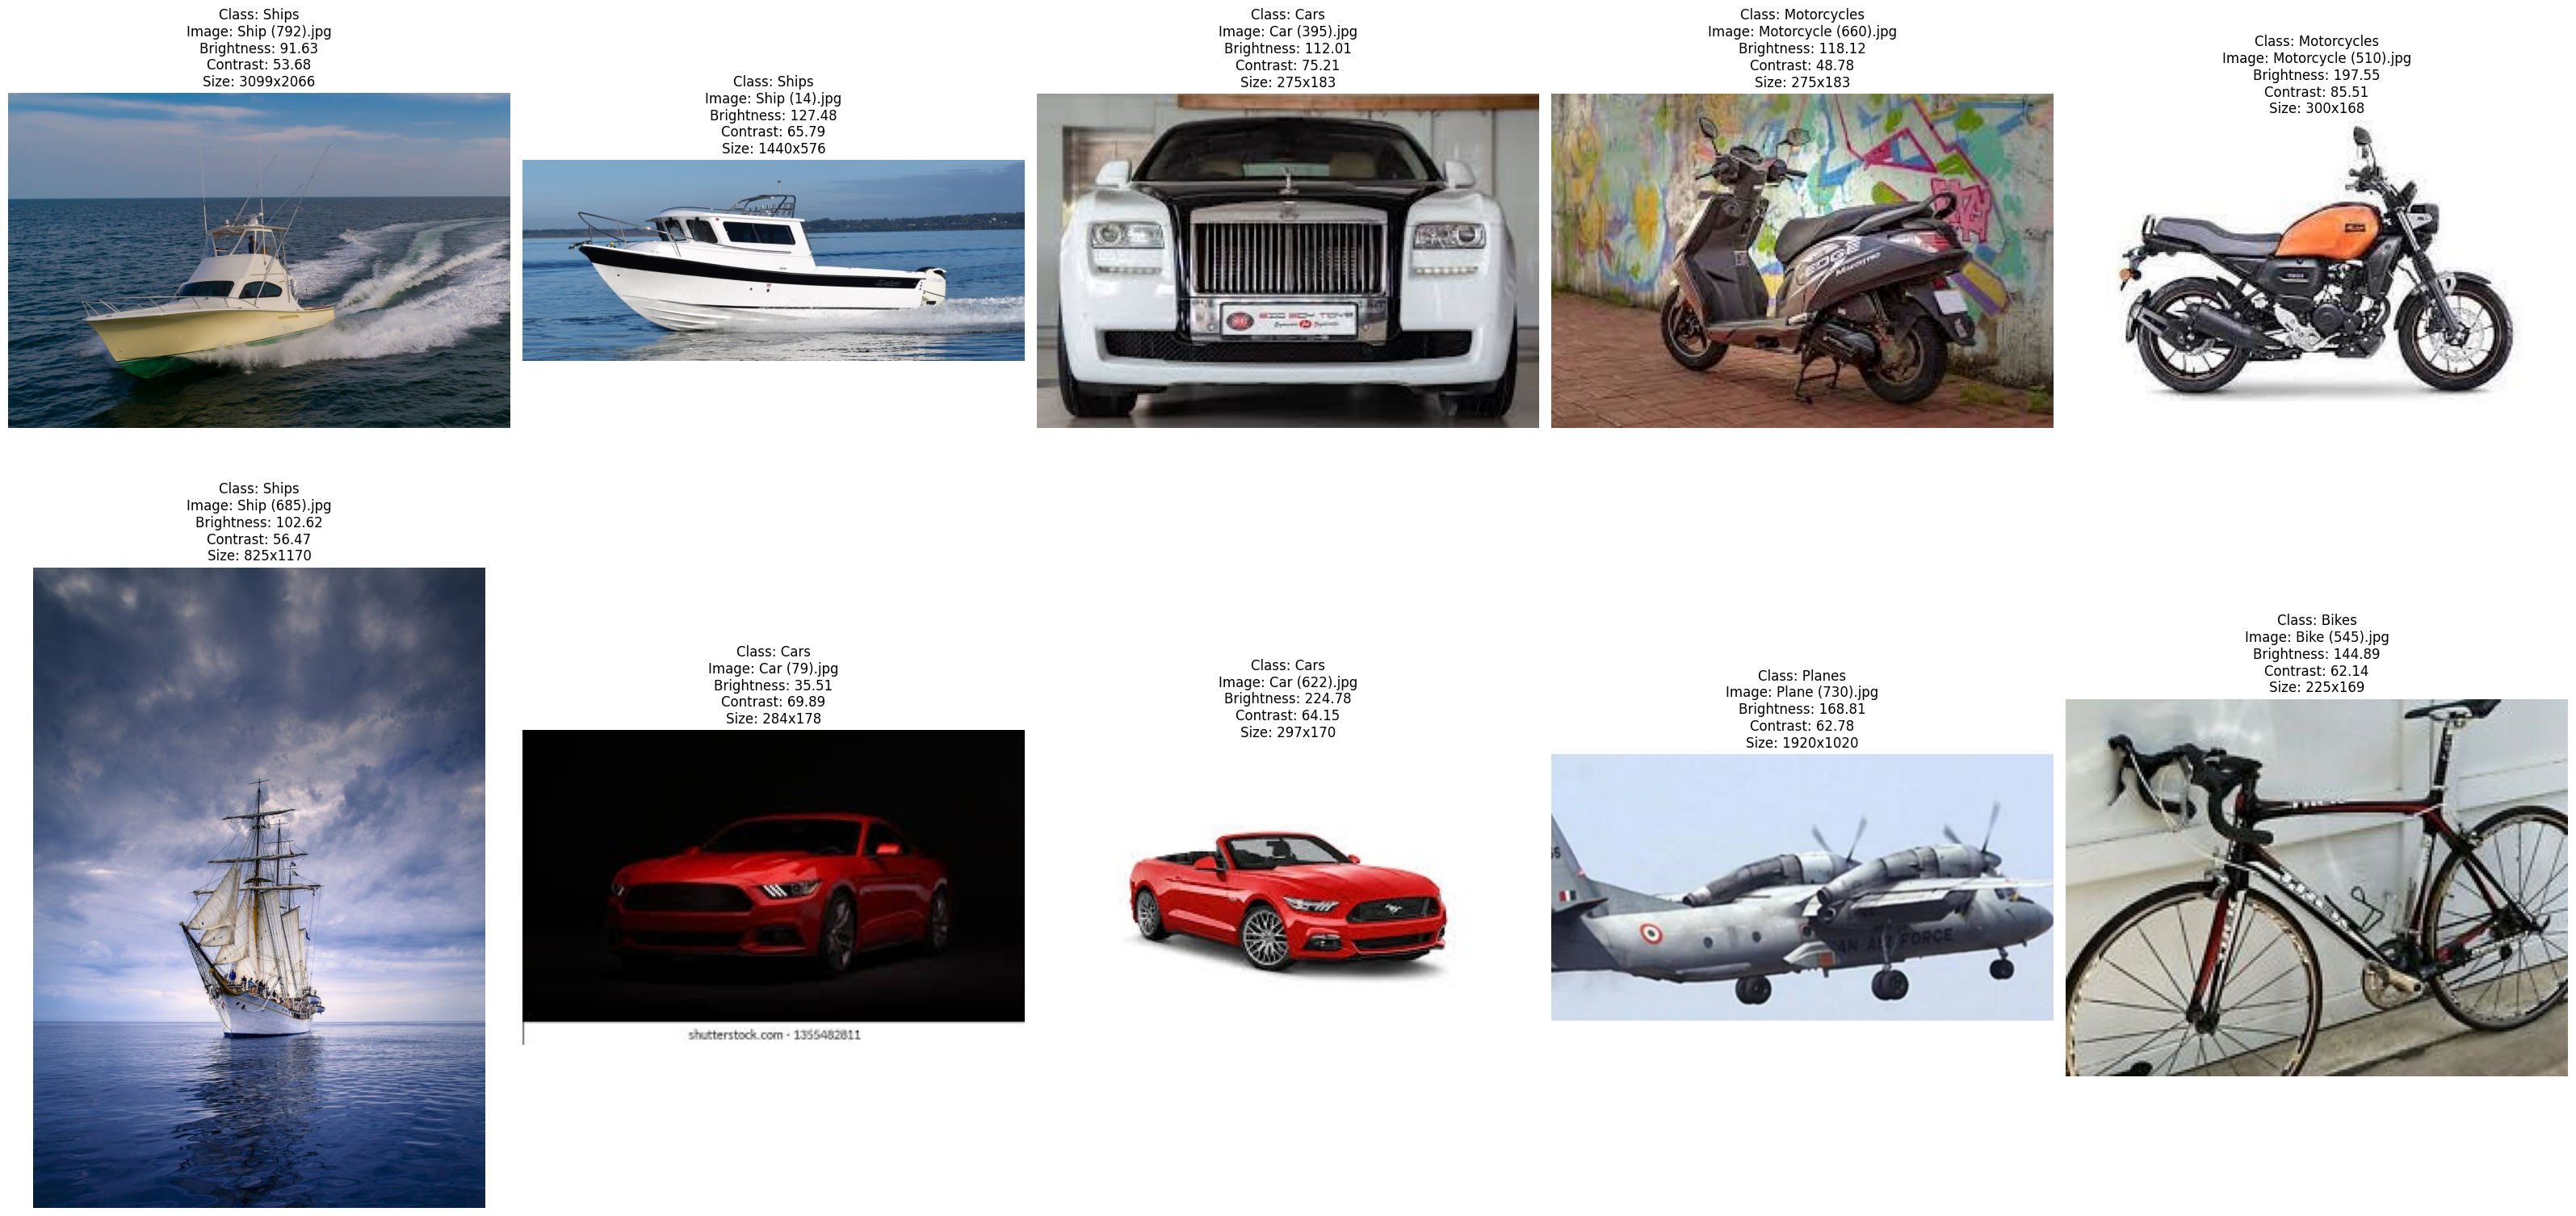

In [ ]:
sample_df = df.sample(n=10, random_state=42)

plt.figure(figsize=(32, 16))

for i, (cls, img_name, full_path) in enumerate(sample_df.values):
    with Image.open(full_path) as img:
        img_rgb = img.convert("RGB")   # always RGB for plotting

        stat = ImageStat.Stat(img_rgb)
        brightness = stat.mean[0]
        contrast = stat.stddev[0]

        width, height = img.size
        print(f"Image: {img_name} | Class: {cls} | Size: {width}x{height} | Brightness: {brightness:.1f} | Contrast: {contrast:.1f}")

        plt.subplot(2, 5, i + 1)
        plt.imshow(img_rgb)   # plot RGB version
        plt.axis('off')
        plt.title(
            f"Class: {cls}\n"
            f"Image: {img_name}\n"
            f"Brightness: {brightness:.2f}\n"
            f"Contrast: {contrast:.2f}\n"
            f"Size: {width}x{height}"
        )

plt.tight_layout()
plt.show()

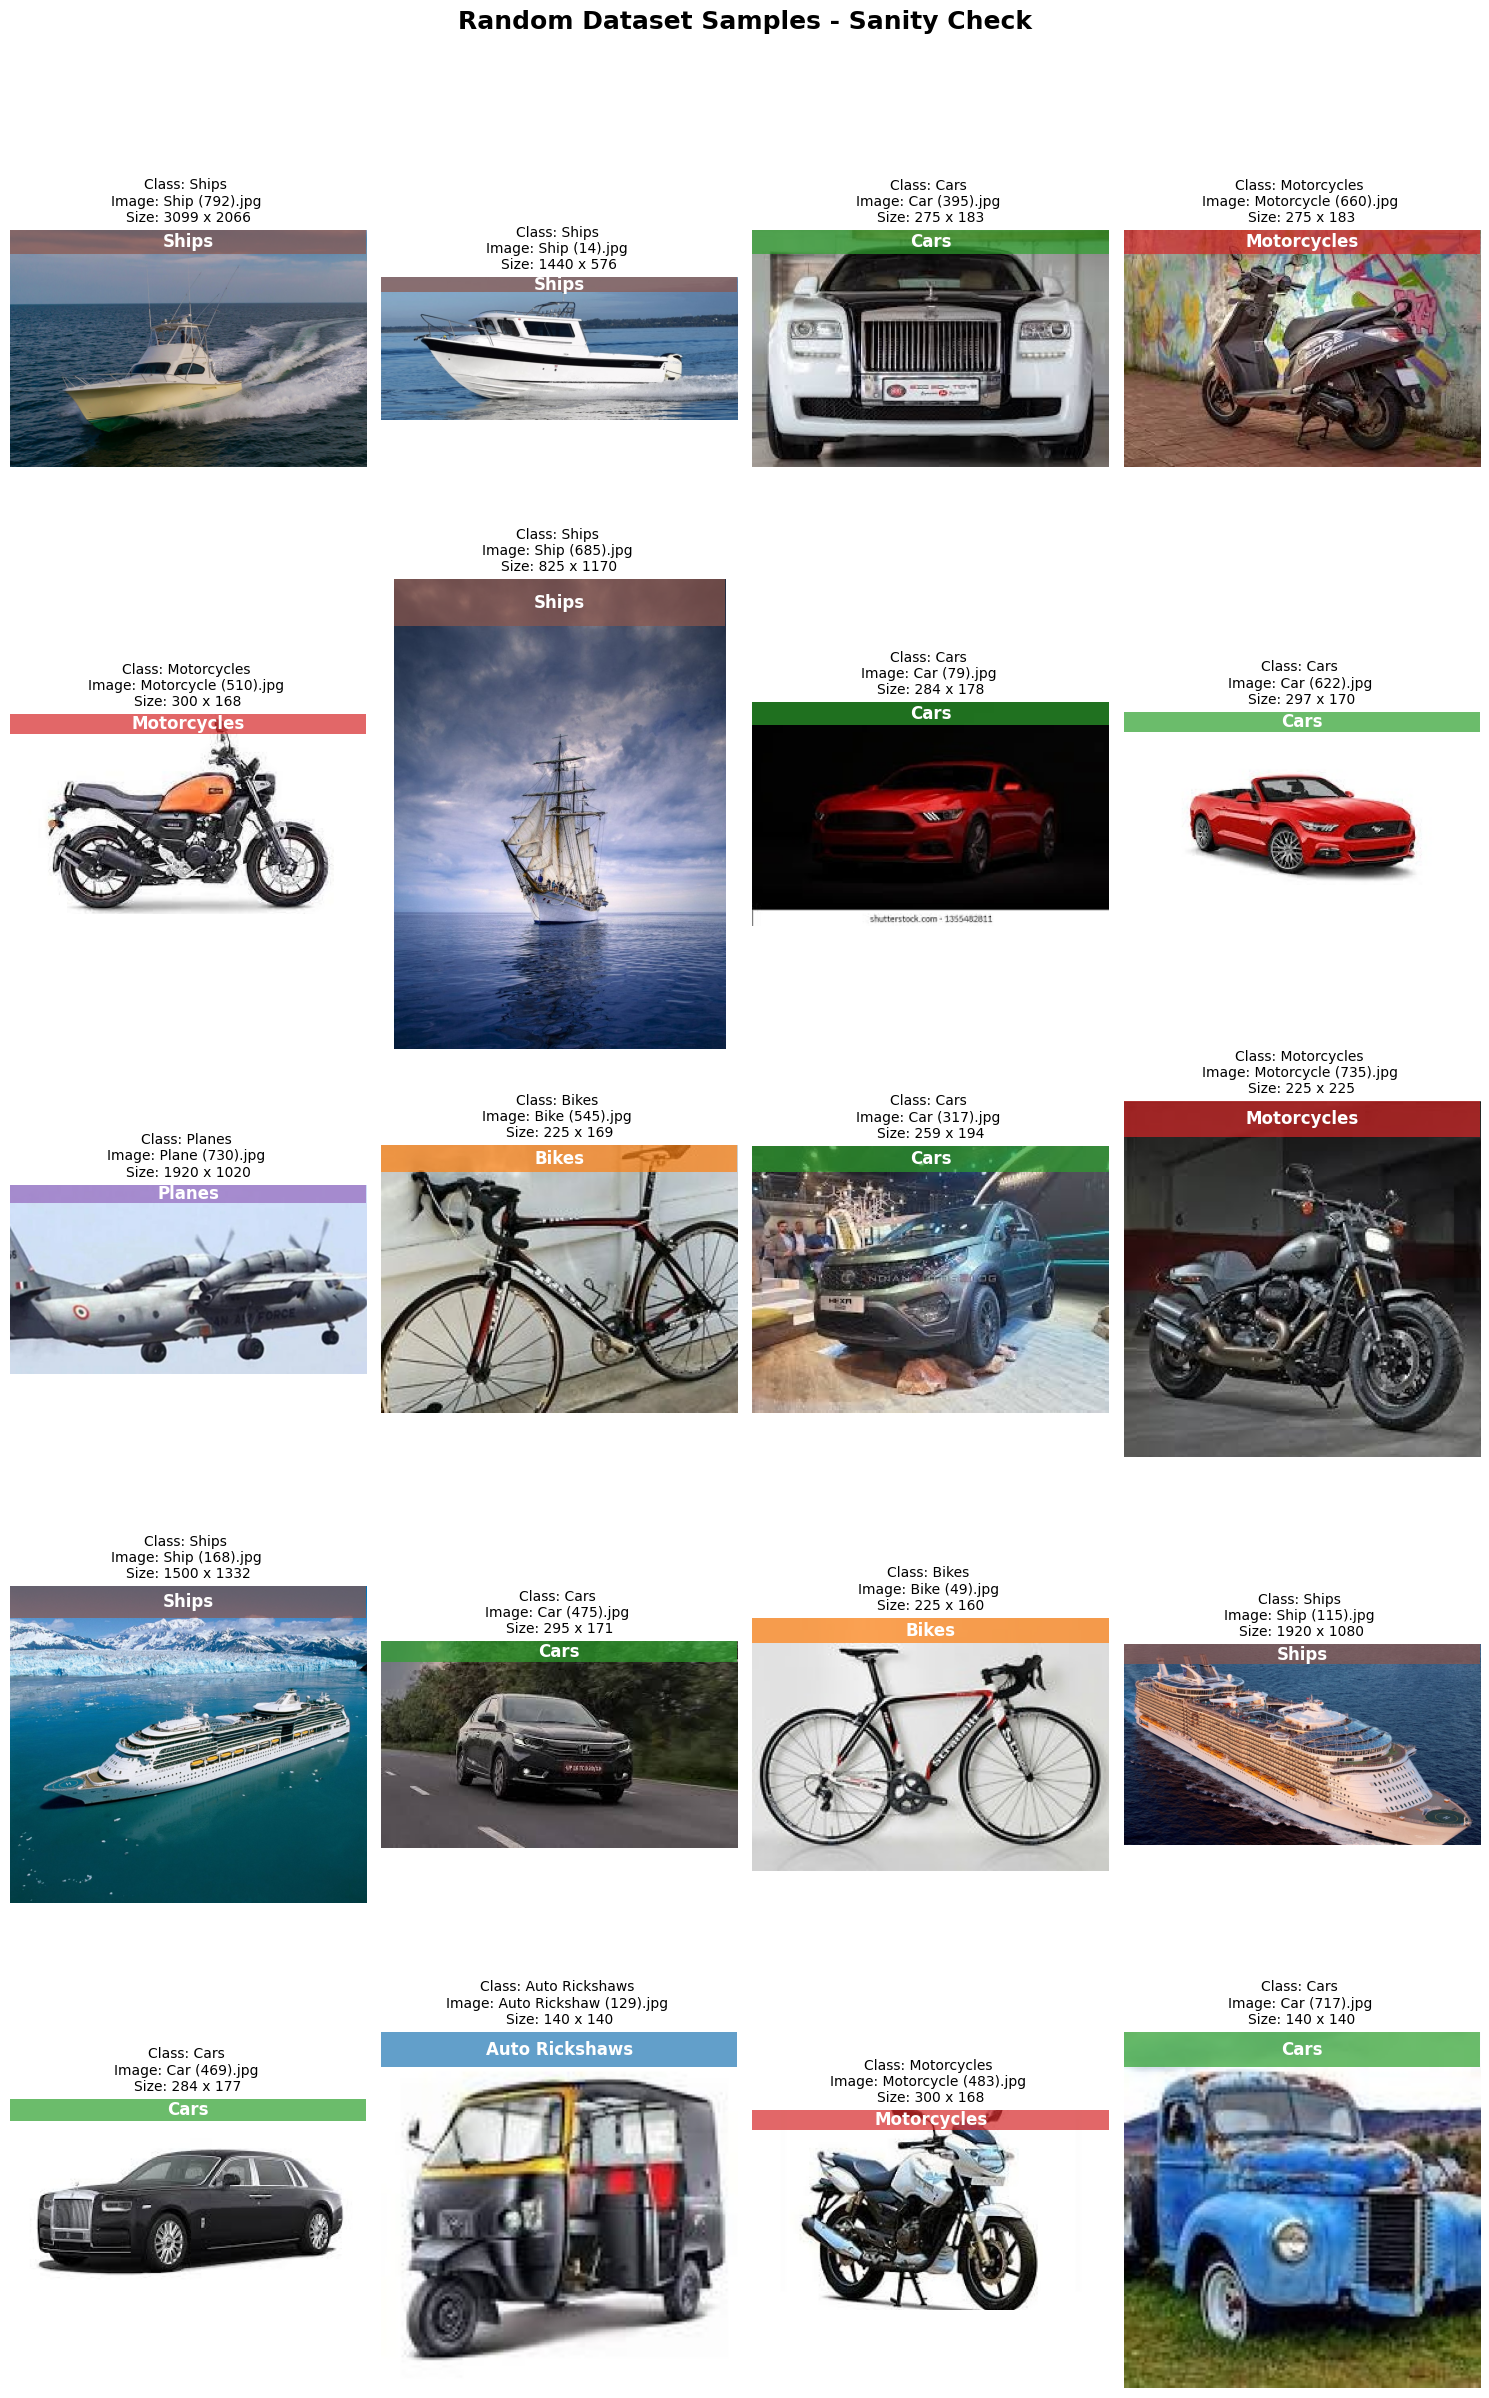

In [ ]:
# Sample 20 random images
num_samples = 20
sample_df = df.sample(num_samples, random_state=42)

# Get sorted class list and color map
classes = sorted(df['class'].unique())
colors = plt.cm.tab10.colors

# Grid setup
cols = 4
rows = num_samples // cols + int(num_samples % cols > 0)

# Figure setup
plt.figure(figsize=(15, 5 * rows))

for idx, (cls, img_name, full_path) in enumerate(sample_df.values):
    with Image.open(full_path) as img:
        img_rgb = img.convert("RGB")
        ax = plt.subplot(rows, cols, idx + 1)
        ax.imshow(img_rgb)
        ax.axis('off')

        # Title with class info
        ax.set_title(
            f"Class: {cls} \nImage: {img_name} \nSize: {img.width} x {img.height}",
            fontsize=10
        )

        # FIXED SIZE RECTANGLE IN AXES COORDINATES
        # Rectangle in axes coords: full width, small height at top
        label_height = 0.1  # 10% of image height
        label_width = 1.0   # full width of the image

        rect = patches.Rectangle(
        (0, 1 - label_height), label_width, label_height,
        transform=ax.transAxes,
        linewidth=0,
        edgecolor=None,
        facecolor=colors[classes.index(cls) % len(colors)],
        alpha=0.7
      )
        ax.add_patch(rect)

        # Add class name text centered horizontally
        ax.text(
        0.5, 1 - label_height / 2,
        cls,
        transform=ax.transAxes,
        fontsize=12,
        color="white",
        fontweight="bold",
        va="center",
        ha="center"
      )

# Figure title and layout
plt.suptitle("Random Dataset Samples - Sanity Check", fontsize=18, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
#Check missing files
print("Missing values per column: ")
print(df.isnull().sum())

#Check duplicate files
duplicate_names = df.duplicated().sum()
print(f"\nNumber of duplicate files: {duplicate_names}")

duplicate_names = df[df.duplicated(subset = ['image'], keep = False)]
print(f"Duplicate file names: {len(duplicate_names)}")

#Check if two images or more are the same even if they are having different file names
def get_hash(file_path):
    with open(file_path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

df['file_hash'] = df['full_path'].apply(get_hash)
duplicate_hashes = df[df.duplicated(subset = ['file_hash'], keep = False)]
print(f"Duplicate image files: {len(duplicate_hashes)}")

#This code below just removing the duplicate files, which means will not be feeded to the model, but will be still in the actual directory
#Important note: duplicates are removed from the dataframe only, not from the actual directory.
#Drop duplicates based on file_hash, keeping the first one

# df_unique = df.drop_duplicates(subset='file_hash', keep='first')
# print(f"After removing duplicates, unique images: {len(df_unique)}")

#Check for images extentions
df['extenstion'] = df['image'].apply(lambda x: Path(x).suffix.lower())
print("File type counts: ")
#print(df['extenstion'].value_counts)
print(df['extenstion'].value_counts())

#Check for resolution relationships
df['Width'] = sizes_df['Width']
df['Height'] = sizes_df['Height']
#print(df.groupby(['Width', 'Height']).size())
print(df.groupby('class')[['Width', 'Height']].agg(['min', 'max', 'mean']))

#Check for class balance (relationship between label and count)
class_summary = df['class'].value_counts(normalize = False).to_frame('Count')
#class_summary['Percentage'] = class_summary['Count'] / class_summary['Count'].sum() * 100
#class_summary
class_summary['Percentage %'] = round((class_summary['Count'] / len(df)) * 100, 2)
print(class_summary)

Missing values per column: 
class        0
image        0
full_path    0
dtype: int64

Number of duplicate files: 0
Duplicate file names: 0
Duplicate image files: 279
File type counts: 
extenstion
.jpg    5600
Name: count, dtype: int64
                Width                      Height                     
                  min     max         mean    min     max         mean
class                                                                 
Auto Rickshaws   63.0  6000.0   449.018750   59.0  4613.0   356.558750
Bikes           127.0   225.0   222.332500   75.0   225.0   164.195000
Cars             92.0  1920.0   230.531250   40.0  1440.0   154.686250
Motorcycles     100.0  1920.0   304.732500   81.0  1689.0   213.817500
Planes          219.0  7260.0  1042.796250  128.0  4630.0   667.691250
Ships           192.0  7993.0  1576.003750  168.0  5995.0  1037.018750
Trains          183.0  4889.0   541.542567  154.0  3024.0   390.250318
                Count  Percentage %
class             

In [ ]:
# Check corrupted files
corrupted_files = []

for file_path in df['full_path']:
    try:
        with Image.open(file_path) as img:
            img.verify()  # Verify file integrity
    except (UnidentifiedImageError, OSError):
        corrupted_files.append(file_path)

print(f"Found {len(corrupted_files)} corrupted images.")

if corrupted_files:
    df = df[~df['full_path'].isin(corrupted_files)].reset_index(drop=True)
    print("Corrupted files removed.")


# Outliers detection (resolution-based)
width_mean = sizes_df['Width'].mean()
width_std = sizes_df['Width'].std()
height_mean = sizes_df['Height'].mean()
height_std = sizes_df['Height'].std()

outliers = df[
    (df['Width'] > width_mean + 3 * width_std) |
    (df['Width'] < width_mean - 3 * width_std) |
    (df['Height'] > height_mean + 3 * height_std) |
    (df['Height'] < height_mean - 3 * height_std)
]
print(f"Found {len(outliers)} resolution outliers.")

# Brightness / Contrast check (without storing images)
too_dark = []
too_bright = []
blank_or_gray = []

# Thresholds
dark_threshold = 30    # Below this is too dark
bright_threshold = 225 # Above this is too bright
low_contrast_threshold = 5  # Low contrast ~ blank/gray

for idx, file_path in enumerate(df['full_path']):
    try:
        with Image.open(file_path).convert('RGB') as img:
            gray = img.convert('L')
            stat = ImageStat.Stat(gray)
            brightness = stat.mean[0]
            contrast = stat.stddev[0]

            if brightness < dark_threshold:
                too_dark.append(file_path)
            elif brightness > bright_threshold:
                too_bright.append(file_path)
            elif contrast < low_contrast_threshold:
                blank_or_gray.append(file_path)
    except Exception as e:
        print(f"Skipping {file_path} due to error: {e}")

print(f"Too dark images: {len(too_dark)}")
print(f"Too bright images: {len(too_bright)}")
print(f"Blank/gray images: {len(blank_or_gray)}")

# (Optional) Drop too bright / blank-gray images
# df = df[~df['full_path'].isin(too_bright + blank_or_gray)].reset_index(drop=True)

# Note: No in-memory enhancement here.
# Enhancements (brightness/contrast adjustments) will be moved into `tf.data` pipeline.

Found 0 corrupted images.
Found 145 resolution outliers.
Too dark images: 14
Too bright images: 48
Blank/gray images: 0


In [ ]:
# Point to the extracted dataset, not the zip file location
dataset_root = "/content/my_data_balanced"

# Check mislabeled images
mismatches = []
for i, row in df.iterrows():
    folder_name = os.path.basename(os.path.dirname(row["full_path"]))
    if row["class"] != folder_name:
        mismatches.append((row["full_path"], row["class"], folder_name))

print(f"Found {len(mismatches)} mislabeled images (class vs folder mismatch).")

# Compare classes vs folders
classes_in_df = set(df["class"].unique())
folders_in_fs = {f for f in os.listdir(dataset_root) if os.path.isdir(os.path.join(dataset_root, f))}

print("Classes in DF but not in folders:", classes_in_df - folders_in_fs)
print("Folders in FS but not in DF:", folders_in_fs - classes_in_df)

Found 0 mislabeled images (class vs folder mismatch).
Classes in DF but not in folders: set()
Folders in FS but not in DF: set()


In [ ]:
def check_file_naming_issues(df):
    issues = {"invalid_chars": [], "spaces": [], "long_paths": [], "case_conflicts": [], "duplicate_names_across_classes": []}

    seen_names = {}

    for _, row in df.iterrows():
        fpath = row["full_path"]              # full path
        fname = os.path.basename(fpath)       # just filename
        cls = row["class"]

        # Invalid characters
        if re.search(r'[<>:"/\\|?*]', fname):  # Windows restricted chars
            issues["invalid_chars"].append(fpath)

        # Spaces
        if "  " in fname or fname.startswith(" ") or fname.endswith(" "):
            issues["spaces"].append(fpath)

        # Long paths
        if len(fpath) > 255:
            issues["long_paths"].append(fpath)

        # Case conflicts
        lower_name = fname.lower()
        if lower_name in seen_names and seen_names[lower_name] != cls:
            issues["case_conflicts"].append((fpath, seen_names[lower_name]))
        else:
            seen_names[lower_name] = cls

    # Duplicate names across classes
    duplicates = df.groupby(df["full_path"].apply(os.path.basename))["class"].nunique()
    duplicates = duplicates[duplicates > 1].index.tolist()
    for dup in duplicates:
        dup_paths = df[df["full_path"].str.endswith(dup)]["full_path"].tolist()
        issues["duplicate_names_across_classes"].extend(dup_paths)

    return issues

# Run the check
naming_issues = check_file_naming_issues(df)

for issue_type, files in naming_issues.items():
    print(f"\n{issue_type.upper()} ({len(files)})")
    for f in files[:10]:  # preview first 10
        print(f)


INVALID_CHARS (0)

SPACES (0)

LONG_PATHS (0)

CASE_CONFLICTS (0)

DUPLICATE_NAMES_ACROSS_CLASSES (0)


In [ ]:
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['class'])
print("Classes found:", le.classes_)

num_classes = len(le.classes_)
print("Number of classes:", num_classes)

Classes found: ['Auto Rickshaws' 'Bikes' 'Cars' 'Motorcycles' 'Planes' 'Ships' 'Trains']
Number of classes: 7


In [ ]:
train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
    df['full_path'], df['label_encoded'],
    test_size=0.1, random_state=42, stratify=df['label_encoded']
)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths, train_val_labels,
    test_size=0.1, random_state=42, stratify=train_val_labels
)

print(f"Train: {len(train_paths)}, Val: {len(val_paths)}, Test: {len(test_paths)}")

Train: 4536, Val: 504, Test: 560


In [ ]:
train_data = {"image": list(train_paths), "label": list(train_labels)}
val_data   = {"image": list(val_paths), "label": list(val_labels)}
test_data  = {"image": list(test_paths), "label": list(test_labels)}

train_ds = Dataset.from_dict(train_data)
val_ds   = Dataset.from_dict(val_data)
test_ds  = Dataset.from_dict(test_data)

In [ ]:
# too_dark = set(map(str, too_dark))
# too_bright = set(map(str, too_bright))

# model_name = "google/vit-base-patch16-224" # You can use smaller model for faster training (model_name = "facebook/deit-tiny-patch16-224")
# processor = AutoImageProcessor.from_pretrained(model_name)                                             # "facebook/deit-small-patch16-224"
#                                                                                                        # We were using or currently using "google/vit-base-patch16-224"
# def preprocess(example):
#     img = Image.open(example["image"]).convert("RGB")
#     img_np = np.array(img)

#     # Light corrections
#     if example["image"] in too_dark:
#         img_np = cv2.convertScaleAbs(img_np, alpha=1.5, beta=30)
#     elif example["image"] in too_bright:
#         img_np = cv2.convertScaleAbs(img_np, alpha=0.9, beta=-30)

#     img = Image.fromarray(img_np)
#     example["pixel_values"] = processor(images=img, return_tensors="pt")["pixel_values"].squeeze()
#     return example

# train_ds = train_ds.map(preprocess)
# val_ds   = val_ds.map(preprocess)
# test_ds  = test_ds.map(preprocess)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


Map:   0%|          | 0/4536 [00:00<?, ? examples/s]

Map:   0%|          | 0/504 [00:00<?, ? examples/s]

Map:   0%|          | 0/560 [00:00<?, ? examples/s]

# **For Fast training, we can preprocess on-the-fly**


In [ ]:
# Image Processor & Model
model_name = "facebook/deit-tiny-patch16-224" # You can use smaller model for faster training (model_name = "facebook/deit-tiny-patch16-224")
processor = AutoImageProcessor.from_pretrained(model_name)                                             # "facebook/deit-small-patch16-224"
                                                                                                       # We were using or currently using "google/vit-base-patch16-224"

too_dark = set(map(str, too_dark))
too_bright = set(map(str, too_bright))

# On-the-fly preprocessing
# Build torch transform once
normalize = transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
size = processor.size.get("shortest_edge", 224)

base_transform = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.ToTensor(),
    normalize,
])

def transform_fn(examples):
    images = []
    for image_path in examples["image"]:
        img = Image.open(image_path).convert("RGB")
        img_np = np.array(img)

        # Light corrections
        if image_path in too_dark:
            img_np = cv2.convertScaleAbs(img_np, alpha=1.5, beta=30)
        elif image_path in too_bright:
            img_np = cv2.convertScaleAbs(img_np, alpha=0.9, beta=-30)

        img = Image.fromarray(img_np)
        images.append(base_transform(img))

    examples["pixel_values"] = images
    return examples

# Apply on-the-fly transforms
train_ds.set_transform(transform_fn)
val_ds.set_transform(transform_fn)
test_ds.set_transform(transform_fn)

# Model
id2label = {i: c for i, c in enumerate(le.classes_)}
label2id = {c: i for i, c in enumerate(le.classes_)}

model = AutoModelForImageClassification.from_pretrained(
    model_name,
    num_labels=len(le.classes_),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

# Collator & Metrics
data_collator = DefaultDataCollator()
accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = torch.argmax(torch.tensor(logits), dim=1)
    return accuracy.compute(predictions=preds, references=labels)

# Training arguments
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=4,
    num_train_epochs=30,
    fp16=True,                        # mixed precision
    dataloader_num_workers=4,         # parallel data loading (fixed typo from "ataloader")
    remove_unused_columns=False,
    metric_for_best_model="accuracy",
    save_total_limit=1,
    load_best_model_at_end=True,
    greater_is_better=True,
    logging_dir="./logs",
    report_to="none",
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=processor,
    compute_metrics=compute_metrics,
)

print(torch.cuda.is_available(), torch.cuda.get_device_name(0))  # GPU check
trainer.train()

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


pytorch_model.bin:   0%|          | 0.00/23.0M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at facebook/deit-tiny-patch16-224 and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 192]) in the checkpoint and torch.Size([7, 192]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([7]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


True Tesla T4


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy
1,0.761600,0.108069,0.986111
2,0.057500,0.045613,0.982143
3,0.013400,0.035360,0.990079
4,0.005700,0.028360,0.986111
5,0.003800,0.025710,0.994048
6,0.003000,0.026422,0.992063
7,0.002500,0.027811,0.992063
8,0.002100,0.028556,0.992063
9,0.001900,0.027257,0.992063
10,0.001700,0.028129,0.992063


TrainOutput(global_step=1080, training_loss=0.029086311480582314, metrics={'train_runtime': 2269.5076, 'train_samples_per_second': 59.96, 'train_steps_per_second': 0.476, 'total_flos': 6.791339021348045e+17, 'train_loss': 0.029086311480582314, 'epoch': 30.0})

In [ ]:
# model = AutoModelForImageClassification.from_pretrained(
#     model_name,
#     num_labels=num_classes,
#     ignore_mismatched_sizes=True
# )

# data_collator = DefaultDataCollator()

# accuracy = evaluate.load("accuracy")

# def compute_metrics(eval_pred):
#     logits, labels = eval_pred
#     preds = torch.argmax(torch.tensor(logits), dim=1)
#     return accuracy.compute(predictions=preds, references=labels)

# training_args = TrainingArguments(
#     output_dir="./results",
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     logging_strategy="epoch", # If you want to trach the accuracy and loss per steps not epoch, simply write (logging_strategy="steps")
#     learning_rate=5e-5,
#     per_device_train_batch_size=32,
#     per_device_eval_batch_size=32,
#     gradient_accumulation_steps=4,
#     num_train_epochs=3,
#     load_best_model_at_end=True,
#     fp16=True, # Enable mixed precision, and (if using an NVIDIA GPU with mixed precision support) → 2× faster training, half the memory
#     remove_unused_columns=False, # avoids removing pixel_values unexpectedly and prevent dropping custom features
#     metric_for_best_model="accuracy",
#     save_total_limit=1,             # Keep only best checkpoints, and just one, we can modify it as we need
#     greater_is_better=True,
#     logging_dir="./logs",
#     report_to="none",
#     #logging_steps=50 # This for showing progress periodically after each 50 steps
# )

# trainer = Trainer(
#     model=model,
#     args=training_args,
#     data_collator=data_collator,
#     train_dataset=train_ds,
#     eval_dataset=val_ds,
#     tokenizer=processor,
#     compute_metrics=compute_metrics,
# )
# print(torch.cuda.is_available(), torch.cuda.get_device_name(0)) # To make sure we using the GPU
# trainer.train()

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([7]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([7, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


True Tesla T4


Epoch,Training Loss,Validation Loss,Accuracy
1,0.392100,0.031671,0.994048
2,0.010800,0.026011,0.994048
3,0.004400,0.025473,0.994048


TrainOutput(global_step=108, training_loss=0.13574508343029906, metrics={'train_runtime': 1854.6908, 'train_samples_per_second': 7.337, 'train_steps_per_second': 0.058, 'total_flos': 1.0545582509178716e+18, 'train_loss': 0.13574508343029906, 'epoch': 3.0})

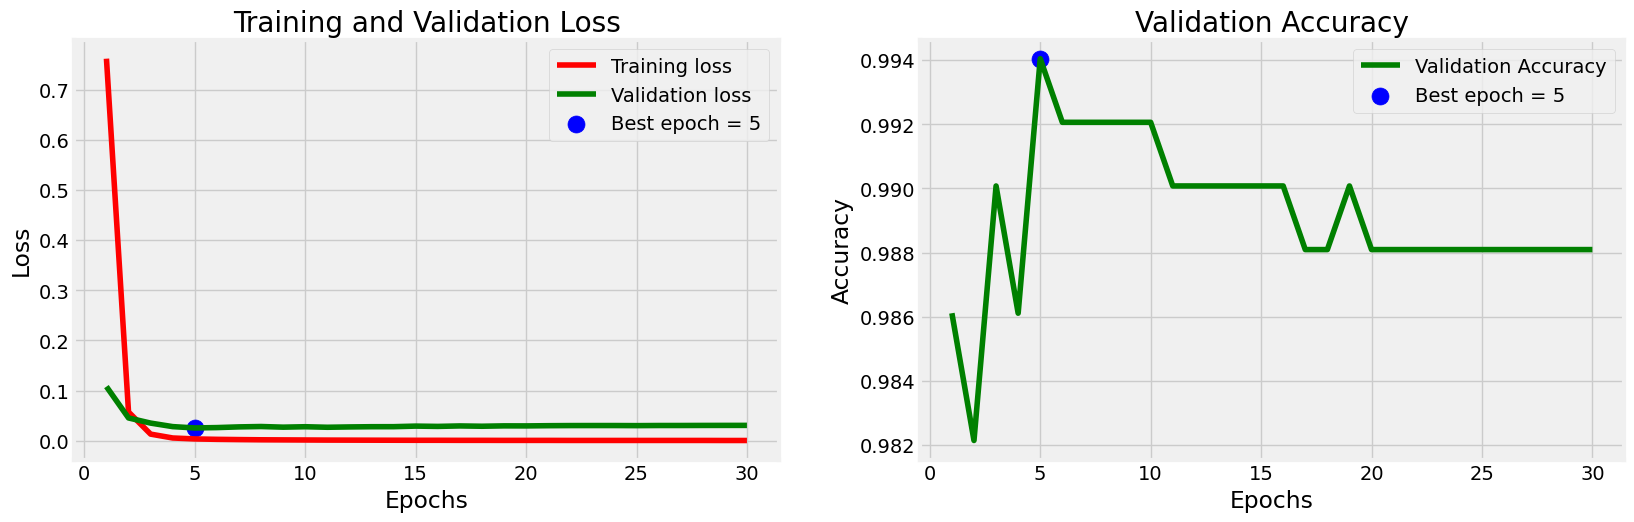

In [ ]:
train_history = trainer.state.log_history  # list of dicts with logs per step/epoch

# Extract all training losses per epoch
tr_loss = []
val_loss = []
val_acc = []

# Only consider epoch-end logs
for log in train_history:
    if "loss" in log and "epoch" in log:
        tr_loss.append(log["loss"])
    if "eval_loss" in log:
        val_loss.append(log["eval_loss"])
    if "eval_accuracy" in log:
        val_acc.append(log["eval_accuracy"])

# Epoch numbers
Epochs = range(1, len(val_acc) + 1)

# Best epochs
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]

index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]

loss_label = f'Best epoch = {str(index_loss + 1)}'
acc_label = f'Best epoch = {str(index_acc + 1)}'

plt.figure(figsize=(20, 12))
plt.style.use('fivethirtyeight')

# Loss
plt.subplot(2, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label='Training loss')
plt.plot(Epochs, val_loss, 'g', label='Validation loss')
plt.scatter(index_loss + 1, val_lowest, s=150, c='blue', label=loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(2, 2, 2)
plt.plot(Epochs, val_acc, 'g', label='Validation Accuracy')
plt.scatter(index_acc + 1, acc_highest, s=150, c='blue', label=acc_label)
plt.title('Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

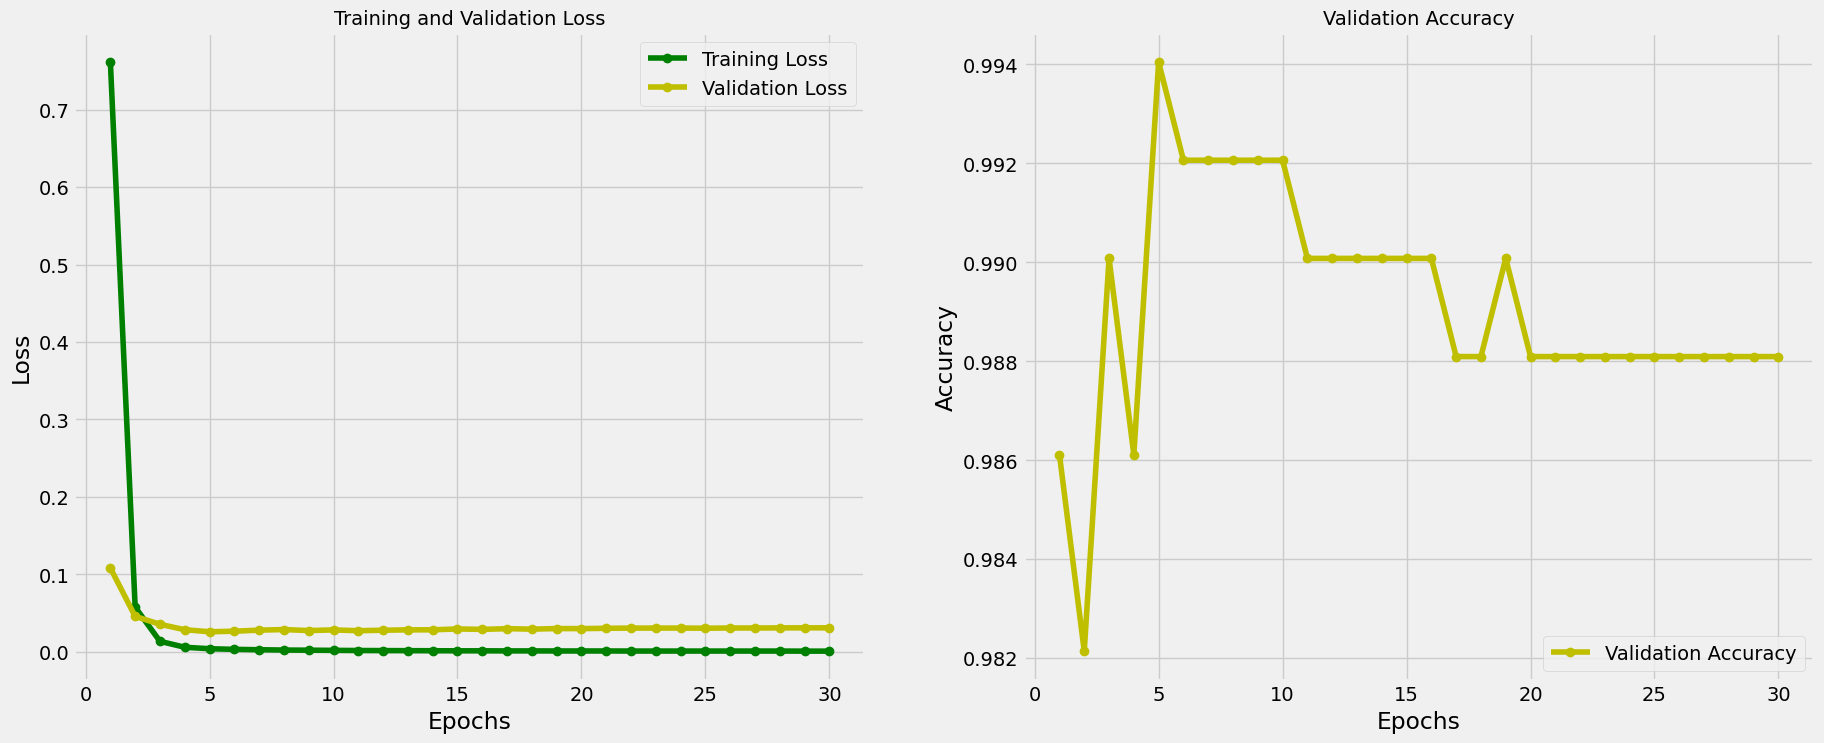

In [ ]:
# Define epochs based on number of validation steps (each corresponds to one epoch)
epochs = range(1, len(val_acc) + 1)

# Now plot
fig, ax = plt.subplots(1, 2)
fig.set_size_inches(20, 8)
plt.style.use("fivethirtyeight")

# Loss
ax[0].plot(epochs, tr_loss[:len(epochs)], 'g-o', label='Training Loss')
ax[0].plot(epochs, val_loss, 'y-o', label='Validation Loss')
ax[0].set_title('Training and Validation Loss', fontsize=14)
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[0].grid(True)

# Accuracy
ax[1].plot(epochs, val_acc, 'y-o', label='Validation Accuracy')
ax[1].set_title('Validation Accuracy', fontsize=14)
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].legend(loc='lower right')
ax[1].grid(True)

plt.show()

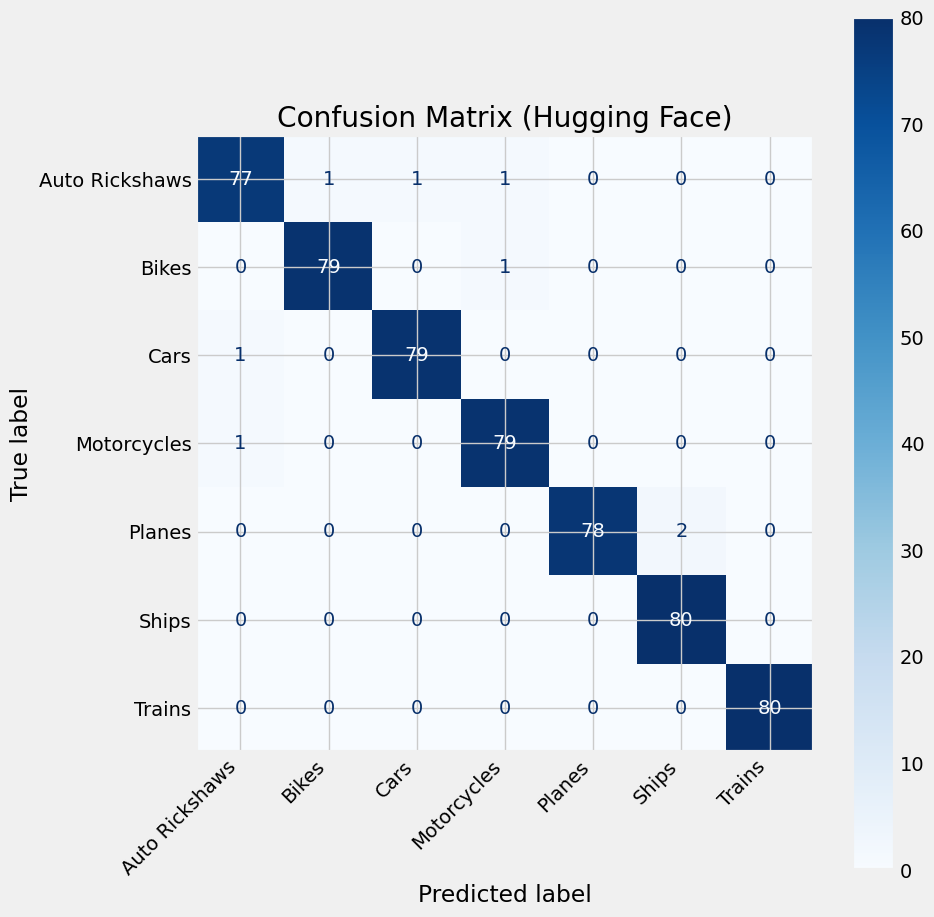

In [ ]:
# Make sure model is on the right device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Run prediction on the test set
pred_results = trainer.predict(test_ds)

# Extract predictions and true labels
y_true = pred_results.label_ids
y_pred = np.argmax(pred_results.predictions, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot it
fig, ax = plt.subplots(figsize=(10, 10))
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
cm_display.plot(cmap='Blues', values_format='d', ax=ax)

plt.xticks(rotation=45, ha='right')
plt.title("Confusion Matrix (Hugging Face)")
plt.tight_layout()
plt.show()

Accuracy: 0.9857
Precision: 0.9858, Recall: 0.9857, F1: 0.9857

Classification Report:
                precision    recall  f1-score   support

Auto Rickshaws       0.97      0.96      0.97        80
         Bikes       0.99      0.99      0.99        80
          Cars       0.99      0.99      0.99        80
   Motorcycles       0.98      0.99      0.98        80
        Planes       1.00      0.97      0.99        80
         Ships       0.98      1.00      0.99        80
        Trains       1.00      1.00      1.00        80

      accuracy                           0.99       560
     macro avg       0.99      0.99      0.99       560
  weighted avg       0.99      0.99      0.99       560



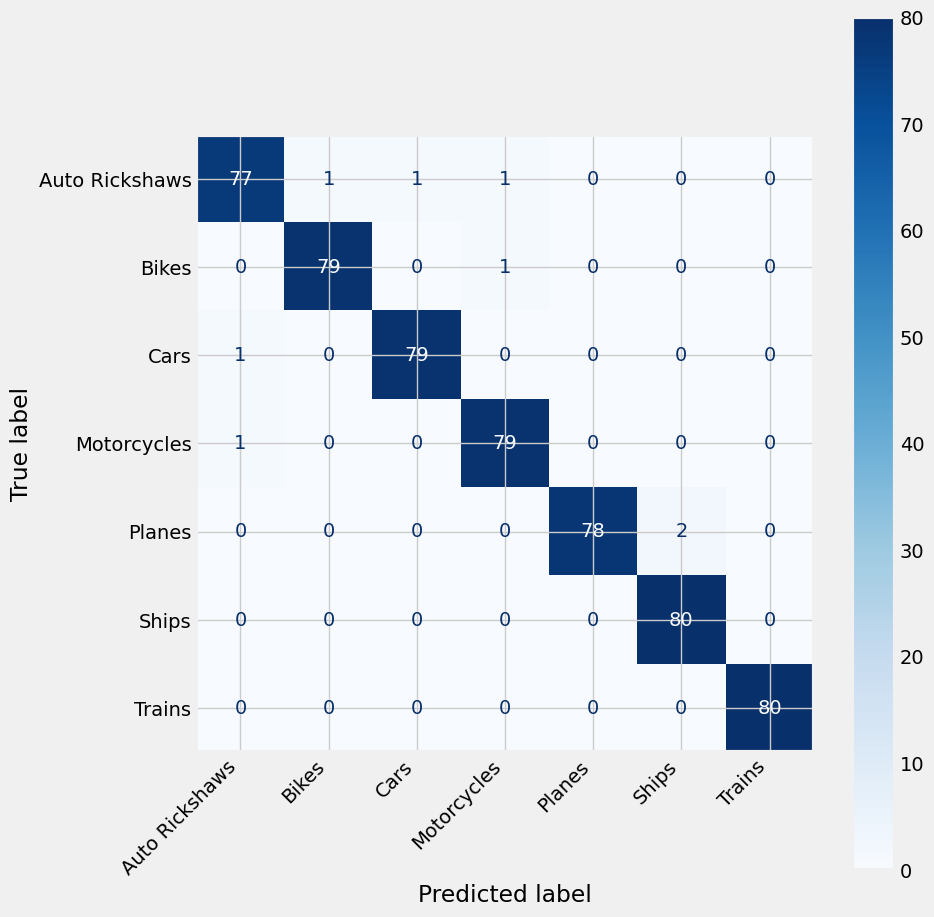

In [ ]:
def evaluate_model(trainer, dataset, class_names):
    results = trainer.predict(dataset)
    y_true = results.label_ids
    y_pred = np.argmax(results.predictions, axis=1)

    # Compute metrics
    accuracy = np.mean(y_true == y_pred)
    precision = precision_score(y_true, y_pred, average="macro")
    recall = recall_score(y_true, y_pred, average="macro")
    f1 = f1_score(y_true, y_pred, average="macro")

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Plot confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(10, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues", values_format="d", ax=ax)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

evaluate_model(trainer, test_ds, le.classes_)

In [ ]:
# Run prediction
pred_results = trainer.predict(test_ds)

# Extract logits, preds, and labels
y_true = pred_results.label_ids
y_logits = pred_results.predictions
y_probs = np.exp(y_logits) / np.sum(np.exp(y_logits), axis=1, keepdims=True)  # softmax
y_pred = np.argmax(y_probs, axis=1)

# Per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    average=None,
    labels=np.arange(len(le.classes_))
)

df_metrics = pd.DataFrame({
    "Class": le.classes_,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "Support": support
})

# Sort by F1-score ascending (optional)
df_metrics_sorted = df_metrics.sort_values(by="F1-score", ascending=True)
print(df_metrics_sorted)

# Macro averages
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro"
)

print(f"\nMacro Avg -> Precision: {precision_macro:.4f}, Recall: {recall_macro:.4f}, F1-score: {f1_macro:.4f}")

# save them for reporting:
# df_metrics_sorted.to_csv("per_class_metrics.csv", index=False)


display(df_metrics_sorted.style.background_gradient(cmap="Blues"))

            Class  Precision  Recall  F1-score  Support
0  Auto Rickshaws   0.974684  0.9625  0.968553       80
3     Motorcycles   0.975309  0.9875  0.981366       80
4          Planes   1.000000  0.9750  0.987342       80
1           Bikes   0.987500  0.9875  0.987500       80
2            Cars   0.987500  0.9875  0.987500       80
5           Ships   0.975610  1.0000  0.987654       80
6          Trains   1.000000  1.0000  1.000000       80

Macro Avg -> Precision: 0.9858, Recall: 0.9857, F1-score: 0.9857


,Class,Precision,Recall,F1-score,Support
0,Auto Rickshaws,0.974684,0.962500,0.968553,80
3,Motorcycles,0.975309,0.987500,0.981366,80
4,Planes,1.000000,0.975000,0.987342,80
1,Bikes,0.987500,0.987500,0.987500,80
2,Cars,0.987500,0.987500,0.987500,80
5,Ships,0.975610,1.000000,0.987654,80
6,Trains,1.000000,1.000000,1.000000,80


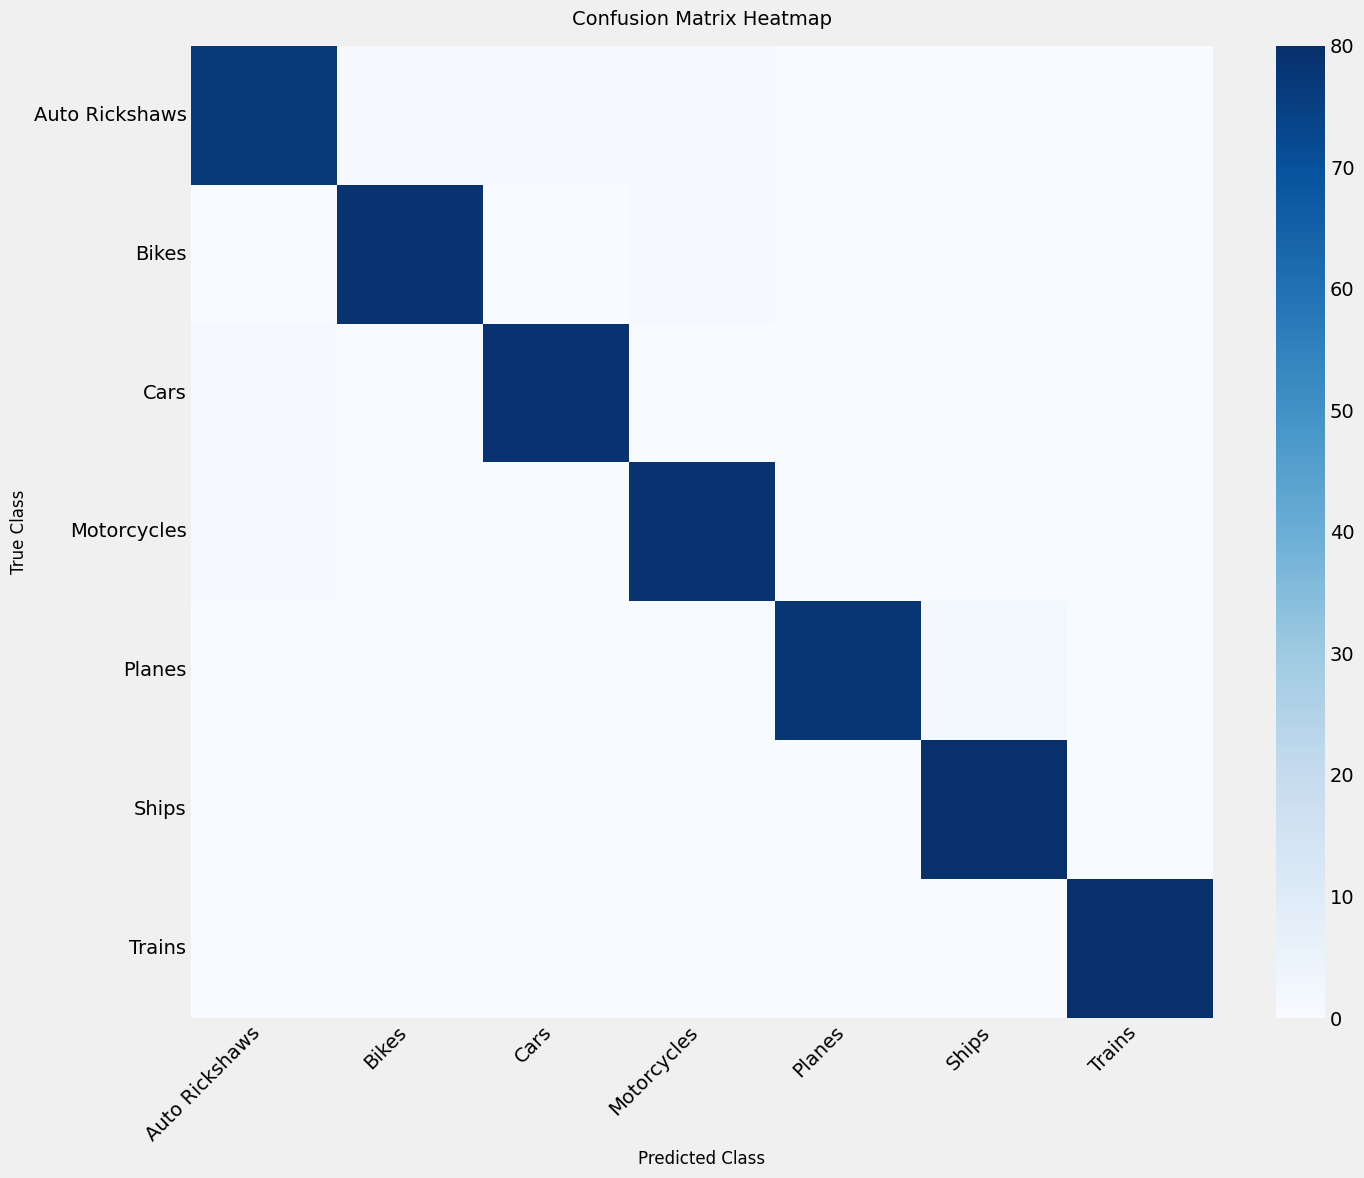

In [ ]:
# Run predictions using Trainer
pred_results = trainer.predict(test_ds)

# Extract true and predicted labels
y_true = pred_results.label_ids
y_pred = np.argmax(pred_results.predictions, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(
    cm,
    annot=False,              # set to True if you want counts shown inside each cell
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("True Class", fontsize=12)
plt.title("Confusion Matrix Heatmap", fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Precision: 0.9858, Recall: 0.9857, F1-score: 0.9857

Classification Report:
                precision    recall  f1-score   support

Auto Rickshaws       0.97      0.96      0.97        80
         Bikes       0.99      0.99      0.99        80
          Cars       0.99      0.99      0.99        80
   Motorcycles       0.98      0.99      0.98        80
        Planes       1.00      0.97      0.99        80
         Ships       0.98      1.00      0.99        80
        Trains       1.00      1.00      1.00        80

      accuracy                           0.99       560
     macro avg       0.99      0.99      0.99       560
  weighted avg       0.99      0.99      0.99       560



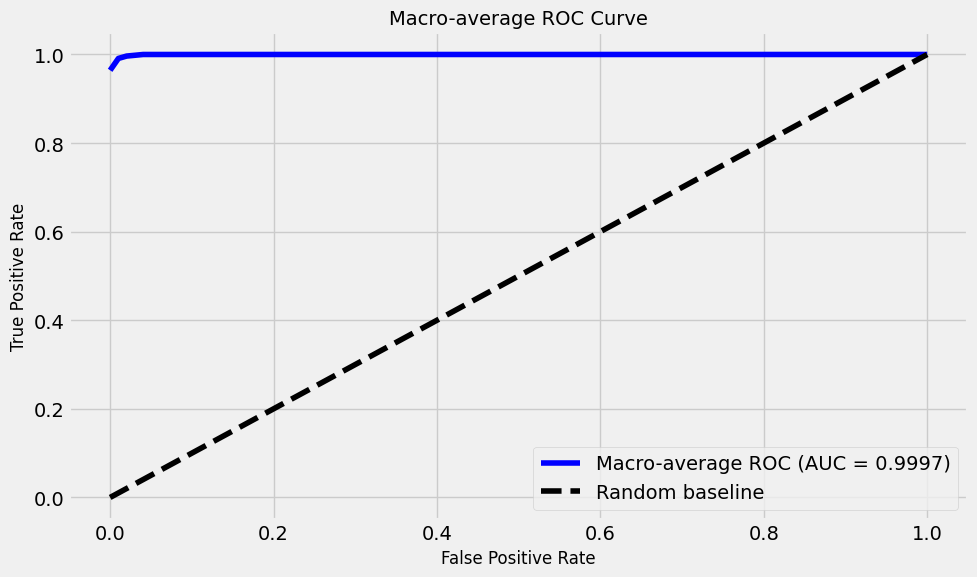

In [ ]:
# Get model predictions and logits from Hugging Face Trainer
pred_results = trainer.predict(test_ds)

# Extract true labels and logits
y_true = pred_results.label_ids
y_logits = pred_results.predictions

# Convert logits → probabilities (softmax)
y_probs = np.exp(y_logits) / np.sum(np.exp(y_logits), axis=1, keepdims=True)

# Predicted labels
y_pred = np.argmax(y_probs, axis=1)

# Basic metrics
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}\n")
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_))

# Binarize the true labels for ROC computation
y_test_bin = label_binarize(y_true, classes=np.arange(len(le.classes_)))

# Prepare the macro-average ROC curve
all_fpr = np.linspace(0, 1, 100)
mean_tpr = 0.0

for i in range(len(le.classes_)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
    mean_tpr += np.interp(all_fpr, fpr, tpr)

# Average TPR across classes
mean_tpr /= len(le.classes_)
roc_auc = auc(all_fpr, mean_tpr)

# Plot the macro-average ROC curve
plt.figure(figsize=(10, 6))
plt.plot(all_fpr, mean_tpr, color='b', label=f'Macro-average ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random baseline')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Macro-average ROC Curve', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

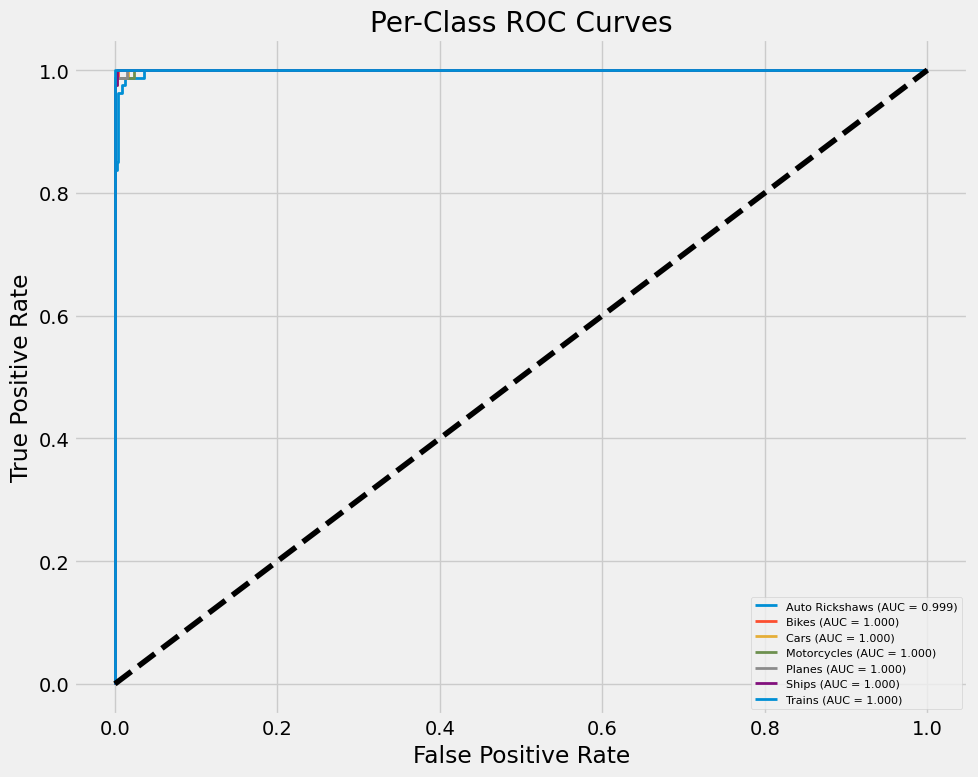

In [ ]:
plt.figure(figsize=(10, 8))
for i, cls in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{cls} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Per-Class ROC Curves')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# Save model and processor/tokenizer
save_dir = "./best_model"

trainer.model.save_pretrained(save_dir, safe_serialization=True)
processor.save_pretrained(save_dir, safe_serialization=True)

print(f"Best model and processor saved to: {save_dir}")

Best model and processor saved to: ./best_model


In [ ]:
# Verify What We Saved
config = AutoConfig.from_pretrained("./best_model")
print(config.id2label)
print(config.label2id)

{0: 'Auto Rickshaws', 1: 'Bikes', 2: 'Cars', 3: 'Motorcycles', 4: 'Planes', 5: 'Ships', 6: 'Trains'}
{'Auto Rickshaws': 0, 'Bikes': 1, 'Cars': 2, 'Motorcycles': 3, 'Planes': 4, 'Ships': 5, 'Trains': 6}


In [ ]:
print("Best model checkpoint:", trainer.state.best_model_checkpoint)
print("Best metric:", trainer.state.best_metric)

best_ckpt = trainer.state.best_model_checkpoint
match = re.search(r"checkpoint-(\d+)", best_ckpt)
if match:
    best_epoch = int(match.group(1))
    print(f"Best epoch: {best_epoch}")
else:
    print("Could not determine best epoch name.")

Best model checkpoint: ./results/checkpoint-180
Best metric: 0.9940476190476191
Best epoch: 180


In [ ]:
trainer.state.log_history[-10:]  # last 10 log entries

with open(f"{trainer.state.best_model_checkpoint}/trainer_state.json") as f:
    data = json.load(f)
print(data["best_metric"])
print(data["best_model_checkpoint"])

steps_per_epoch = len(train_ds) // training_args.per_device_train_batch_size
best_epoch_est = int(int(re.search(r"\d+", trainer.state.best_model_checkpoint).group()) / steps_per_epoch)
print(f"Estimated best epoch ≈ {best_epoch_est}")

# Convert log history to DataFrame
log_df = pd.DataFrame(trainer.state.log_history)

# Filter only evaluation entries
eval_df = log_df[log_df["train_runtime"].isna() & log_df["eval_accuracy"].notna()]

# Find the row with the best accuracy
best_row = eval_df.loc[eval_df["eval_accuracy"].idxmax()]

print(f"Best validation accuracy: {best_row['eval_accuracy']:.4f}")
print(f"Best epoch: {best_row['epoch']}")
print(f"Best checkpoint: {trainer.state.best_model_checkpoint}")


0.9940476190476191
./results/checkpoint-180
Estimated best epoch ≈ 1
Best validation accuracy: 0.9940
Best epoch: 5.0
Best checkpoint: ./results/checkpoint-180


In [ ]:
shutil.make_archive("best_model", "zip", save_dir)
files.download("best_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Reload It Anywhere (for Inference or Deployment)**

**Later, for deployment (e.g., FastAPI, Streamlit, Flask, etc.):**

In [ ]:
# Load from the saved directory
model = AutoModelForImageClassification.from_pretrained("./best_model")
processor = AutoImageProcessor.from_pretrained("./best_model")

model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Example inference
img = Image.open("test_image.jpg").convert("RGB")
inputs = processor(images=img, return_tensors="pt").to(device)
outputs = model(**inputs)
pred = torch.argmax(outputs.logits, dim=1).item()

# Decode class label if available
print(f"Predicted class: {pred}")

In [ ]:
# Push the Best Model to Hugging Face Hub
model.push_to_hub("your-username/your-model-name")
processor.push_to_hub("your-username/your-model-name")

# You can load as:
model = AutoModelForImageClassification.from_pretrained("your-username/your-model-name")
processor = AutoImageProcessor.from_pretrained("your-username/your-model-name")